# Notebook 08.1: Real Population Analysis — filespopulation27 Dataset

Runs the full crossing, equilibrium, and optimization pipeline on the **filespopulation27** SRK genotype dataset.
Data loading and genotype assignment are performed inline (no separate notebook 00 run required).

**Analysis structure:**
1. **Within-population analysis** — All major populations (≥5 individuals) analysed independently
2. **Cross-population analysis** — All ingroup individuals treated as a single metapopulation

**PNG output:** Figures for Pop 27 and the cross-population analysis are saved individually to `outputs/figures/`.

In [62]:
import os
import sys
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import chisquare

sns.set_style("whitegrid")
np.random.seed(42)
random.seed(42)

# Import all shared utilities
sys.path.insert(0, "../src")
from polyploid_utils import (
    canonical, allele_frequencies, form_gametes, is_compatible,
    cross, crossing_compatibility, sample_offspring, simulate_generation,
    distance_from_equilibrium, enumerate_compatible_crosses,
    compute_greedy_weights, compute_optimal_weights,
    identify_rare_alleles, get_mandatory_rare_crosses, select_elites,
    logistic_n_offspring, effective_population_size, ne_harmonic_mean,
)

# Directories
DATA_DIR = os.path.join("..", "data", "filespopulation27")
FIGURES_DIR = os.path.join("..", "outputs", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Color scheme (consistent throughout)
COLOR_RANDOM = "#8e8e8e"
COLOR_PRESERVED = "#1565c0"
COLOR_ORIGINAL = "#c62828"
COLOR_DEMOGRAPHIC = "#2e7d32"

# Simulation parameters
N_YEARS = 5
N_TRIALS = 10
SNAPSHOT_YEARS = [0, 1, 2, 3]
BASE_SEED = 42
MAJOR_POP_THRESHOLD = 5

print("Imports loaded. Figures will be saved to:", os.path.abspath(FIGURES_DIR))

Imports loaded. Figures will be saved to: /Users/sven/Documents/Current_projects/SRK_bioinformatics/SRK_bioinformatics_GitHub/modeling/outputs/figures


## 1. Load and Process Data

Loads the five data files from `data/filespopulation27/`, filters to ingroup individuals,
and assigns deterministic tetraploid genotypes from zygosity patterns:
- **AAAA** (homozygous): 4 copies of a single allele
- **AABB** (two-allele): 2 copies each of two alleles
- **ABCD** (four-allele): 1 copy each of four alleles
- **AABC** (three-allele): doubled allele resolved by read depth

In [4]:
# --- Load all five data files ---
zygosity_df    = pd.read_csv(os.path.join(DATA_DIR, "SRK_individual_zygosity.tsv"), sep="\t")
genotypes_df   = pd.read_csv(os.path.join(DATA_DIR, "SRK_individual_genotypes.tsv"), sep="\t")
protein_table  = pd.read_csv(os.path.join(DATA_DIR, "SRK_individual_protein_table.tsv"), sep="\t")
metadata_df    = pd.read_csv(os.path.join(DATA_DIR, "sampling_metadata.csv"))

protein_columns = [c for c in genotypes_df.columns if c != "Individual"]

print("File shapes:")
print(f"  Zygosity:    {zygosity_df.shape[0]} individuals x {zygosity_df.shape[1]} columns")
print(f"  Genotypes:   {genotypes_df.shape[0]} individuals x {len(protein_columns)} proteins")
print(f"  Metadata:    {metadata_df.shape[0]} samples")
print(f"\nZygosity distribution:")
print(zygosity_df["Genotype"].value_counts().to_string())

File shapes:
  Zygosity:    166 individuals x 4 columns
  Genotypes:   166 individuals x 228 proteins
  Metadata:    178 samples

Zygosity distribution:
Genotype
AABB       55
AAAA       54
AABC       33
ABCD       18
Unknown     6


In [5]:
# --- Filter to ingroup individuals only ---
zyg_individuals = set(zygosity_df["Individual"])
meta_individuals = set(metadata_df["SampleID"])

no_metadata = zyg_individuals - meta_individuals
outgroup_ids = set(metadata_df[metadata_df["Ingroup"] == 0]["SampleID"])
outgroup_with_data = outgroup_ids & zyg_individuals

# Exclude individuals with 'Unknown' genotype pattern (>4 detected proteins — ambiguous assignment)
unknown_ids = set(zygosity_df[zygosity_df["Genotype"] == "Unknown"]["Individual"])

exclude_ids = outgroup_with_data | no_metadata | unknown_ids

print(f"Excluded: {len(outgroup_with_data)} outgroup + {len(no_metadata)} no-metadata + "
      f"{len(unknown_ids)} unknown-pattern = {len(exclude_ids)} total")
if unknown_ids:
    print(f"  Unknown-pattern individuals (>4 detected proteins): {sorted(unknown_ids)}")

zygosity_filtered = zygosity_df[~zygosity_df["Individual"].isin(exclude_ids)].copy().reset_index(drop=True)
genotypes_filtered = genotypes_df[~genotypes_df["Individual"].isin(exclude_ids)].copy().reset_index(drop=True)

print(f"Ingroup individuals retained: {len(zygosity_filtered)}")
print("Genotype patterns:")
print(zygosity_filtered["Genotype"].value_counts().to_string())

Excluded: 7 outgroup + 1 no-metadata + 6 unknown-pattern = 14 total
  Unknown-pattern individuals (>4 detected proteins): ['Library002_barcode40', 'Library002_barcode41', 'Library005_barcode04', 'Library005_barcode07', 'Library007_barcode74', 'Library007_barcode76']
Ingroup individuals retained: 152
Genotype patterns:
Genotype
AAAA    51
AABB    51
AABC    32
ABCD    18


In [6]:
def assign_genotype(individual, genotype_pattern, detected_proteins, protein_reads):
    """Assign a tetraploid genotype from zygosity pattern and detected proteins.

    Parameters
    ----------
    individual : str
        Individual identifier.
    genotype_pattern : str
        One of 'AAAA', 'AABB', 'AABC', 'ABCD'.
    detected_proteins : list[str]
        Protein names detected (binary genotype matrix == 1).
    protein_reads : dict[str, int]
        Read counts per protein for this individual.

    Returns
    -------
    tuple[str, ...]
        Sorted 4-element tuple of protein names.
    str
        Assignment method description.
    """
    proteins = sorted(detected_proteins)
    if genotype_pattern == "AAAA":
        assert len(proteins) == 1, f"{individual}: AAAA but {len(proteins)} proteins"
        return tuple(proteins * 4), "homozygous_4x"
    elif genotype_pattern == "AABB":
        assert len(proteins) == 2, f"{individual}: AABB but {len(proteins)} proteins"
        return tuple(sorted(proteins * 2)), "heterozygous_2x2"
    elif genotype_pattern == "ABCD":
        assert len(proteins) == 4, f"{individual}: ABCD but {len(proteins)} proteins"
        return tuple(proteins), "heterozygous_1x4"
    elif genotype_pattern == "AABC":
        assert len(proteins) == 3, f"{individual}: AABC but {len(proteins)} proteins"
        read_counts = {p: protein_reads.get(p, 0) for p in proteins}
        doubled = max(proteins, key=lambda p: (read_counts[p], p))
        singles = [p for p in proteins if p != doubled]
        return tuple(sorted([doubled, doubled] + singles)), f"heterozygous_2x1x1 (doubled={doubled})"
    else:
        raise ValueError(f"Unknown genotype pattern: {genotype_pattern}")


# Build per-individual read counts from protein table
reads_by_individual = {}
for ind, group in protein_table.groupby("Individual"):
    reads_by_individual[ind] = group.groupby("Protein").size().to_dict()

# Assign genotypes
assignments = []
for _, row in zygosity_filtered.iterrows():
    ind = row["Individual"]
    pattern = row["Genotype"]
    geno_row = genotypes_filtered[genotypes_filtered["Individual"] == ind]
    detected = [col for col in protein_columns if geno_row[col].values[0] == 1]
    ind_reads = reads_by_individual.get(ind, {})
    genotype, method = assign_genotype(ind, pattern, detected, ind_reads)
    assignments.append({
        "individual": ind, "genotype_pattern": pattern,
        "n_proteins": row["N_proteins"], "detected_proteins": detected,
        "genotype": genotype, "method": method,
    })

assignments_df = pd.DataFrame(assignments)
print(f"Assigned genotypes for {len(assignments_df)} individuals")
print(assignments_df["method"].apply(lambda m: m.split(" (")[0]).value_counts().to_string())

Assigned genotypes for 152 individuals
method
homozygous_4x         51
heterozygous_2x2      51
heterozygous_2x1x1    32
heterozygous_1x4      18


In [7]:
# --- Map protein names to integer IDs ---
sorted_protein_names = sorted(protein_columns)
name_to_id = {name: i + 1 for i, name in enumerate(sorted_protein_names)}
id_to_name = {v: k for k, v in name_to_id.items()}
allele_pool_full = sorted(name_to_id.values())

# Convert genotypes to integer IDs
population_genotypes = []
individual_names = []
for _, row in assignments_df.iterrows():
    int_genotype = tuple(sorted(name_to_id[p] for p in row["genotype"]))
    population_genotypes.append(int_genotype)
    individual_names.append(row["individual"])

# --- Population grouping ---
meta_lookup = metadata_df.set_index("SampleID")[["Pop", "EO_w_sub"]]
pop_map = {}
for ind in individual_names:
    pop_map[ind] = str(meta_lookup.loc[ind, "Pop"]) if ind in meta_lookup.index else "unknown"

assignments_df["pop"] = assignments_df["individual"].map(pop_map)

pop_populations = {}   # pop -> list of integer genotype tuples
pop_individuals = {}   # pop -> list of individual names
for i, (_, row) in enumerate(assignments_df.iterrows()):
    pop = row["pop"]
    pop_populations.setdefault(pop, []).append(population_genotypes[i])
    pop_individuals.setdefault(pop, []).append(row["individual"])

# Core alleles: present in 2+ individuals
ingroup_geno = genotypes_filtered.set_index("Individual")[protein_columns]
protein_prevalence = ingroup_geno.sum(axis=0).astype(int).sort_values(ascending=False)
detected_proteins = protein_prevalence[protein_prevalence > 0]
core_protein_names = detected_proteins[detected_proteins >= 2].index.tolist()
core_allele_ids = sorted([name_to_id[p] for p in core_protein_names])
n_singletons = (detected_proteins == 1).sum()

print(f"Total proteins detected: {len(detected_proteins)}")
print(f"Singletons: {n_singletons}  |  Core (2+ individuals): {len(core_allele_ids)}")
print(f"Total individuals: {len(population_genotypes)}")
print(f"Populations: {len(pop_populations)}")

Total proteins detected: 202
Singletons: 141  |  Core (2+ individuals): 61
Total individuals: 152
Populations: 26


## 2. Population Overview

=== Major Populations (≥5 individuals) ===
Pop          N  Alleles  Unique geno     Chi-sq   Variance
--------------------------------------------------------
25          32       42           26     1.5378   0.000872
27          30       48           30     0.3533   0.000153
67          32       41           31     0.5315   0.000316
76          25       33           24     0.7226   0.000664

=== Minor Populations (22 pops, <5 individuals) ===
Total individuals in minor pops: 33

=== All Individuals Combined ===
Total: 152 individuals, 202 alleles, 142 unique genotypes
Chi-squared: 1.0218, Variance: 0.000025


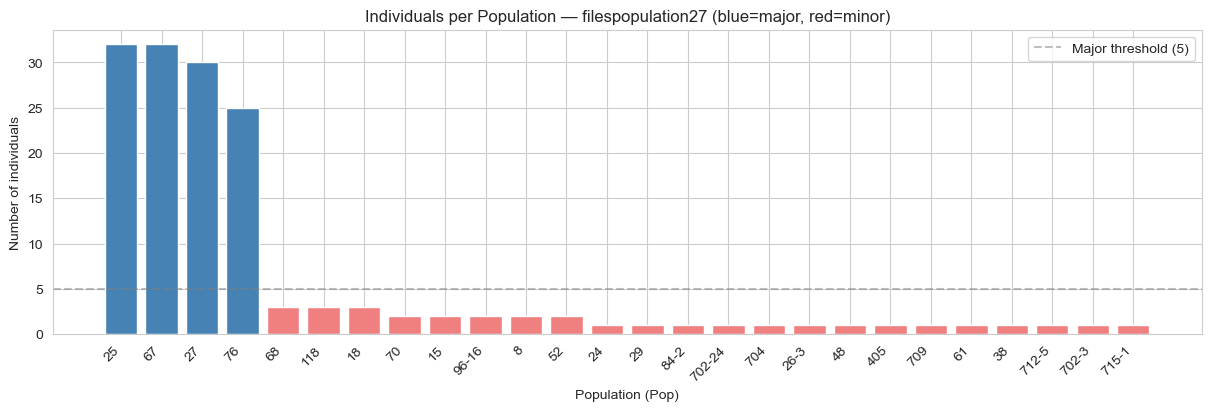

In [9]:
pop_counts = pd.Series({p: len(v) for p, v in pop_populations.items()}).sort_values(ascending=False)
major_pops = sorted([p for p, inds in pop_populations.items() if len(inds) >= MAJOR_POP_THRESHOLD])
minor_pops = sorted([p for p, inds in pop_populations.items() if len(inds) < MAJOR_POP_THRESHOLD])

print(f"=== Major Populations (≥{MAJOR_POP_THRESHOLD} individuals) ===")
print(f"{'Pop':<8} {'N':>5} {'Alleles':>8} {'Unique geno':>12} {'Chi-sq':>10} {'Variance':>10}")
print("-" * 56)
for pop in major_pops:
    genotypes = pop_populations[pop]
    alleles = sorted(set(a for g in genotypes for a in g))
    d = distance_from_equilibrium(genotypes, alleles)
    print(f"{pop:<8} {len(genotypes):>5} {len(alleles):>8} {len(set(genotypes)):>12} "
          f"{d['chi_squared']:>10.4f} {d['variance']:>10.6f}")

minor_total = sum(len(pop_populations[p]) for p in minor_pops)
print(f"\n=== Minor Populations ({len(minor_pops)} pops, <{MAJOR_POP_THRESHOLD} individuals) ===")
print(f"Total individuals in minor pops: {minor_total}")

all_alleles_global = sorted(set(a for g in population_genotypes for a in g))
d_all = distance_from_equilibrium(population_genotypes, all_alleles_global)
print(f"\n=== All Individuals Combined ===")
print(f"Total: {len(population_genotypes)} individuals, {len(all_alleles_global)} alleles, "
      f"{len(set(population_genotypes))} unique genotypes")
print(f"Chi-squared: {d_all['chi_squared']:.4f}, Variance: {d_all['variance']:.6f}")

# Population size bar chart
fig, ax = plt.subplots(figsize=(12, 4), layout="constrained")
pops_sorted = pop_counts.index.tolist()
colors = ["steelblue" if c >= MAJOR_POP_THRESHOLD else "lightcoral" for c in pop_counts.values]
ax.bar(range(len(pops_sorted)), pop_counts.values, color=colors, edgecolor="white")
ax.set_xticks(range(len(pops_sorted)))
ax.set_xticklabels(pops_sorted, rotation=45, ha="right")
ax.set_xlabel("Population (Pop)")
ax.set_ylabel("Number of individuals")
ax.set_title("Individuals per Population — filespopulation27 (blue=major, red=minor)")
ax.axhline(y=MAJOR_POP_THRESHOLD, color="gray", linestyle="--", alpha=0.5, label=f"Major threshold ({MAJOR_POP_THRESHOLD})")
ax.legend()
plt.show()

## Part A: Within-Population Analysis

For each major population (≥5 individuals):
1. Enumerate all SI-compatible crosses
2. Optimize crossing weights via L-BFGS-B (minimise χ² from uniform allele frequencies)
3. Run 10-trial adaptive simulations for 5 years under 4 strategies

In [11]:
%%time

group_data = {}

for pop in major_pops:
    genotypes = pop_populations[pop]
    names = pop_individuals[pop]
    alleles = sorted(set(a for g in genotypes for a in g))
    target = 1.0 / len(alleles)

    cc, aem = enumerate_compatible_crosses(genotypes, alleles)
    n_total = len(genotypes) * (len(genotypes) - 1)

    group_data[pop] = {
        "pop": genotypes,
        "individuals": names,
        "allele_pool": alleles,
        "target_freq": target,
        "compatible_crosses": cc,
        "allele_effect_matrix": aem,
    }
    print(f"Pop {pop}: {len(genotypes)} ind, {len(alleles)} alleles, "
          f"{len(cc)}/{n_total} compatible crosses ({100*len(cc)/n_total:.1f}%)")

Pop 25: 32 ind, 42 alleles, 948/992 compatible crosses (95.6%)
Pop 27: 30 ind, 48 alleles, 863/870 compatible crosses (99.2%)
Pop 67: 32 ind, 41 alleles, 978/992 compatible crosses (98.6%)
Pop 76: 25 ind, 33 alleles, 577/600 compatible crosses (96.2%)
CPU times: user 215 ms, sys: 1.98 ms, total: 217 ms
Wall time: 72.9 ms


In [12]:
%%time

for pop in major_pops:
    gd = group_data[pop]
    cc = gd["compatible_crosses"]
    aem = gd["allele_effect_matrix"]
    alleles = gd["allele_pool"]
    n_crosses = len(cc)
    target = gd["target_freq"]

    w0 = np.ones(n_crosses) / n_crosses
    expected = w0 @ aem
    baseline_chi = float(np.sum((expected - target) ** 2 / target))

    optimal_weights, result = compute_optimal_weights(cc, aem, alleles, maxiter=5000)
    gd["optimal_weights"] = optimal_weights
    gd["opt_result"] = result
    gd["baseline_chi"] = baseline_chi

    print(f"Pop {pop}: baseline χ²={baseline_chi:.4f}, "
          f"optimized χ²={result.fun:.6f}, converged={result.success}")

Pop 25: baseline χ²=1.3173, optimized χ²=0.032787, converged=True
Pop 27: baseline χ²=0.3409, optimized χ²=0.019830, converged=True
Pop 67: baseline χ²=0.4949, optimized χ²=0.014722, converged=True
Pop 76: baseline χ²=0.6411, optimized χ²=0.084285, converged=True
CPU times: user 1.38 s, sys: 272 ms, total: 1.66 s
Wall time: 178 ms


### Within-Population Simulation (5 Years)

Four strategies, 10 stochastic trials each. Seeds are matched across strategies per trial number so the only variable is the crossing strategy.

- **Random** (gray): uniform random pairing among SI-compatible pairs
- **Optimized** (red): L-BFGS-B weights, no rare-allele protection
- **Optimized + preservation** (blue): adds elitism, mandatory rare-allele crosses, and optimizer penalty
- **Optimized + preservation + demography** (green): adds logistic population growth with Poisson noise

In [14]:
def run_adaptive_simulation(pop, allele_pool, n_gen, strategy, n_trials=10,
                            opt_maxiter=200, preserve_rare=False,
                            rare_threshold=0.05, elite_frac=0.1,
                            carrying_capacity=None, growth_rate=0.5,
                            demographic_stochastic=True, base_seed=42,
                            verbose=False):
    """Run multi-trial adaptive simulation with optional preservation and demography.

    Parameters
    ----------
    pop : list[tuple]
        Starting population genotypes.
    allele_pool : list[int]
        All allele IDs to track.
    n_gen : int
        Number of generations to simulate.
    strategy : str
        'random' or 'optimized'.
    n_trials : int
        Number of independent stochastic trials.
    opt_maxiter : int
        L-BFGS-B max iterations per generation.
    preserve_rare : bool
        If True, apply elitism + mandatory rare-allele crosses + optimizer penalty.
    rare_threshold : float
        Allele frequency below which allele is considered rare.
    elite_frac : float
        Fraction of top-rarity individuals carried forward unchanged.
    carrying_capacity : int or None
        If set, population size follows logistic growth toward this K.
    growth_rate : float
        Intrinsic growth rate r for logistic growth.
    demographic_stochastic : bool
        Add Poisson noise to offspring count.
    base_seed : int
        Trial t uses seed base_seed + t (shared across strategies for fair comparison).

    Returns
    -------
    dict
        Mean and std arrays for variance, chi-squared, extinct alleles,
        endangered alleles, population size, Ne, and snapshots.
    """
    all_variances   = np.zeros((n_trials, n_gen + 1))
    all_chi_sq      = np.zeros((n_trials, n_gen + 1))
    all_extinct     = np.zeros((n_trials, n_gen + 1))
    all_endangered  = np.zeros((n_trials, n_gen + 1))
    all_pop_sizes   = np.zeros((n_trials, n_gen + 1))
    all_ne          = np.zeros((n_trials, n_gen + 1))
    snapshots = {}

    for trial in range(n_trials):
        if verbose:
            print(f"    trial {trial+1}/{n_trials}...", end=" ", flush=True)
        np.random.seed(base_seed + trial)
        random.seed(base_seed + trial)
        current_pop = list(pop)

        for gen in range(n_gen + 1):
            d = distance_from_equilibrium(current_pop, allele_pool)
            all_variances[trial, gen]  = d["variance"]
            all_chi_sq[trial, gen]     = d["chi_squared"]
            all_extinct[trial, gen]    = d["extinct_alleles"]
            all_endangered[trial, gen] = d["endangered_alleles"]
            all_pop_sizes[trial, gen]  = len(current_pop)

            if len(current_pop) <= 60:
                ne_info = effective_population_size(current_pop, allele_pool)
                all_ne[trial, gen] = ne_info["Ne"]
            else:
                all_ne[trial, gen] = np.nan

            if trial == n_trials - 1:
                snapshots[gen] = list(current_pop)

            if gen < n_gen:
                if carrying_capacity is not None:
                    n_off = logistic_n_offspring(
                        len(current_pop), carrying_capacity,
                        r=growth_rate, stochastic=demographic_stochastic)
                else:
                    n_off = len(pop)  # fixed at original size

                if strategy == "random":
                    current_pop = simulate_generation(
                        current_pop, n_offspring=n_off,
                        allele_pool=allele_pool if preserve_rare else None,
                        preserve_rare=preserve_rare,
                        rare_threshold=rare_threshold,
                        elite_frac=elite_frac,
                    )
                else:
                    cc, aem = enumerate_compatible_crosses(current_pop, allele_pool)
                    rare_idx = None
                    if preserve_rare:
                        freqs = allele_frequencies(current_pop, allele_pool)
                        sorted_alleles = sorted(allele_pool)
                        rare_idx = [i for i, a in enumerate(sorted_alleles)
                                    if 0 < freqs.get(a, 0) < rare_threshold]
                    weights, _ = compute_optimal_weights(
                        cc, aem, allele_pool, maxiter=opt_maxiter,
                        rare_allele_indices=rare_idx,
                    )
                    plan = [(cc[k][0], cc[k][1], weights[k])
                            for k in range(len(cc)) if weights[k] > 1e-6]
                    current_pop = simulate_generation(
                        current_pop, n_offspring=n_off, crossing_plan=plan,
                        allele_pool=allele_pool if preserve_rare else None,
                        preserve_rare=preserve_rare,
                        rare_threshold=rare_threshold,
                        elite_frac=elite_frac,
                    )

        if verbose:
            print("done")
    return {
        "variance_mean":    all_variances.mean(axis=0),
        "variance_std":     all_variances.std(axis=0),
        "chi_sq_mean":      all_chi_sq.mean(axis=0),
        "chi_sq_std":       all_chi_sq.std(axis=0),
        "extinct_mean":     all_extinct.mean(axis=0),
        "extinct_std":      all_extinct.std(axis=0),
        "endangered_mean":  all_endangered.mean(axis=0),
        "endangered_std":   all_endangered.std(axis=0),
        "pop_size_mean":    all_pop_sizes.mean(axis=0),
        "pop_size_std":     all_pop_sizes.std(axis=0),
        "ne_mean":          np.where(np.all(np.isnan(all_ne), axis=0), np.nan, np.nanmean(all_ne, axis=0)),
        "ne_std":           np.where(np.all(np.isnan(all_ne), axis=0), np.nan, np.nanstd(all_ne, axis=0)),
        "snapshots":        snapshots,
    }

In [15]:
%%time

for pop_id in major_pops:
    gd = group_data[pop_id]
    pop = gd["pop"]
    alleles = gd["allele_pool"]
    N0 = len(pop)
    K = max(N0 * 3, 30)
    print(f"\nPop {pop_id} ({N0} ind, {len(alleles)} alleles, K={K}):")

    print("  Random mating...")
    gd["random"] = run_adaptive_simulation(
        pop, alleles, N_YEARS, "random", N_TRIALS, base_seed=BASE_SEED)

    print("  Optimized (no preservation)...")
    gd["optimized"] = run_adaptive_simulation(
        pop, alleles, N_YEARS, "optimized", N_TRIALS, base_seed=BASE_SEED)

    print("  Optimized + preservation...")
    gd["preserved"] = run_adaptive_simulation(
        pop, alleles, N_YEARS, "optimized", N_TRIALS,
        opt_maxiter=50, preserve_rare=True, rare_threshold=0.05, elite_frac=0.1,
        base_seed=BASE_SEED, verbose=True)

    print("  Optimized + preservation + demography...")
    gd["demographic"] = run_adaptive_simulation(
        pop, alleles, N_YEARS, "optimized", N_TRIALS,
        opt_maxiter=50, preserve_rare=True, rare_threshold=0.05, elite_frac=0.1,
        carrying_capacity=K, growth_rate=0.5, demographic_stochastic=True,
        base_seed=BASE_SEED, verbose=True)

    r = gd["random"]; o = gd["optimized"]; p = gd["preserved"]; dm = gd["demographic"]
    for yr in SNAPSHOT_YEARS:
        if yr <= N_YEARS:
            imp_o = (1 - o["variance_mean"][yr] / max(r["variance_mean"][yr], 1e-12)) * 100
            imp_p = (1 - p["variance_mean"][yr] / max(r["variance_mean"][yr], 1e-12)) * 100
            imp_d = (1 - dm["variance_mean"][yr] / max(r["variance_mean"][yr], 1e-12)) * 100
            print(f"  Year {yr}: Random var={r['variance_mean'][yr]:.6f}, "
                  f"Opt={o['variance_mean'][yr]:.6f} ({imp_o:.0f}%), "
                  f"Pres={p['variance_mean'][yr]:.6f} ({imp_p:.0f}%), "
                  f"Demo={dm['variance_mean'][yr]:.6f} ({imp_d:.0f}%)")
            print(f"           Extinct: R={r['extinct_mean'][yr]:.1f}, "
                  f"O={o['extinct_mean'][yr]:.1f}, P={p['extinct_mean'][yr]:.1f}, "
                  f"D={dm['extinct_mean'][yr]:.1f} | "
                  f"Pop size (demo): {dm['pop_size_mean'][yr]:.0f}")

print("\nDone.")


Pop 25 (32 ind, 42 alleles, K=96):
  Random mating...
  Optimized (no preservation)...
  Optimized + preservation...
    trial 1/10... done
    trial 2/10... done
    trial 3/10... done
    trial 4/10... done
    trial 5/10... done
    trial 6/10... done
    trial 7/10... done
    trial 8/10... done
    trial 9/10... done
    trial 10/10... done
  Optimized + preservation + demography...
    trial 1/10... done
    trial 2/10... done
    trial 3/10... done
    trial 4/10... done
    trial 5/10... done
    trial 6/10... done
    trial 7/10... done
    trial 8/10... done
    trial 9/10... done
    trial 10/10... done
  Year 0: Random var=0.000872, Opt=0.000872 (0%), Pres=0.000872 (0%), Demo=0.000872 (0%)
           Extinct: R=0.0, O=0.0, P=0.0, D=0.0 | Pop size (demo): 32
  Year 1: Random var=0.000946, Opt=0.000250 (74%), Pres=0.000170 (82%), Demo=0.000171 (82%)
           Extinct: R=8.1, O=3.2, P=0.0, D=0.0 | Pop size (demo): 43
  Year 2: Random var=0.000950, Opt=0.000238 (75%), Pres=0.

/var/folders/7q/9sxlsr1j6xg80n7_3mmyx_nr0000gp/T/ipykernel_91674/2326443061.py:127: RuntimeWarning: Mean of empty slice
  "ne_mean":          np.where(np.all(np.isnan(all_ne), axis=0), np.nan, np.nanmean(all_ne, axis=0)),
/Users/sven/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Optimized + preservation...
    trial 1/10... done
    trial 2/10... done
    trial 3/10... done
    trial 4/10... done
    trial 5/10... done
    trial 6/10... done
    trial 7/10... done
    trial 8/10... done
    trial 9/10... done
    trial 10/10... done
  Optimized + preservation + demography...
    trial 1/10... done
    trial 2/10... done
    trial 3/10... done
    trial 4/10... done
    trial 5/10... done
    trial 6/10... done
    trial 7/10... done
    trial 8/10... done
    trial 9/10... done
    trial 10/10... done
  Year 0: Random var=0.000153, Opt=0.000153 (0%), Pres=0.000153 (0%), Demo=0.000153 (0%)
           Extinct: R=0.0, O=0.0, P=0.0, D=0.0 | Pop size (demo): 30
  Year 1: Random var=0.000404, Opt=0.000225 (44%), Pres=0.000109 (73%), Demo=0.000100 (75%)
           Extinct: R=11.3, O=6.5, P=0.0, D=0.0 | Pop size (demo): 44
  Year 2: Random var=0.000606, Opt=0.000242 (60%), Pres=0.000120 (80%), Demo=0.000101 (83%)
           Extinct: R=16.3, O=9.2, P=0.0, D=0.0 | Pop

### Allele Frequency Distributions by Strategy

**Chart Set 1** — Random (gray) vs. Optimized + Preservation (blue): shows how managed crossing drives allele bars toward the dashed equilibrium target.

**Chart Set 2** — Original Optimization (red) vs. Optimized + Preservation (blue): red bars disappearing over time indicate allele extinction; blue bars maintain all alleles.

Pop 27 figures are saved as individual PNGs.

  Saved: ../outputs/figures/pop25_allele_freq_random.png


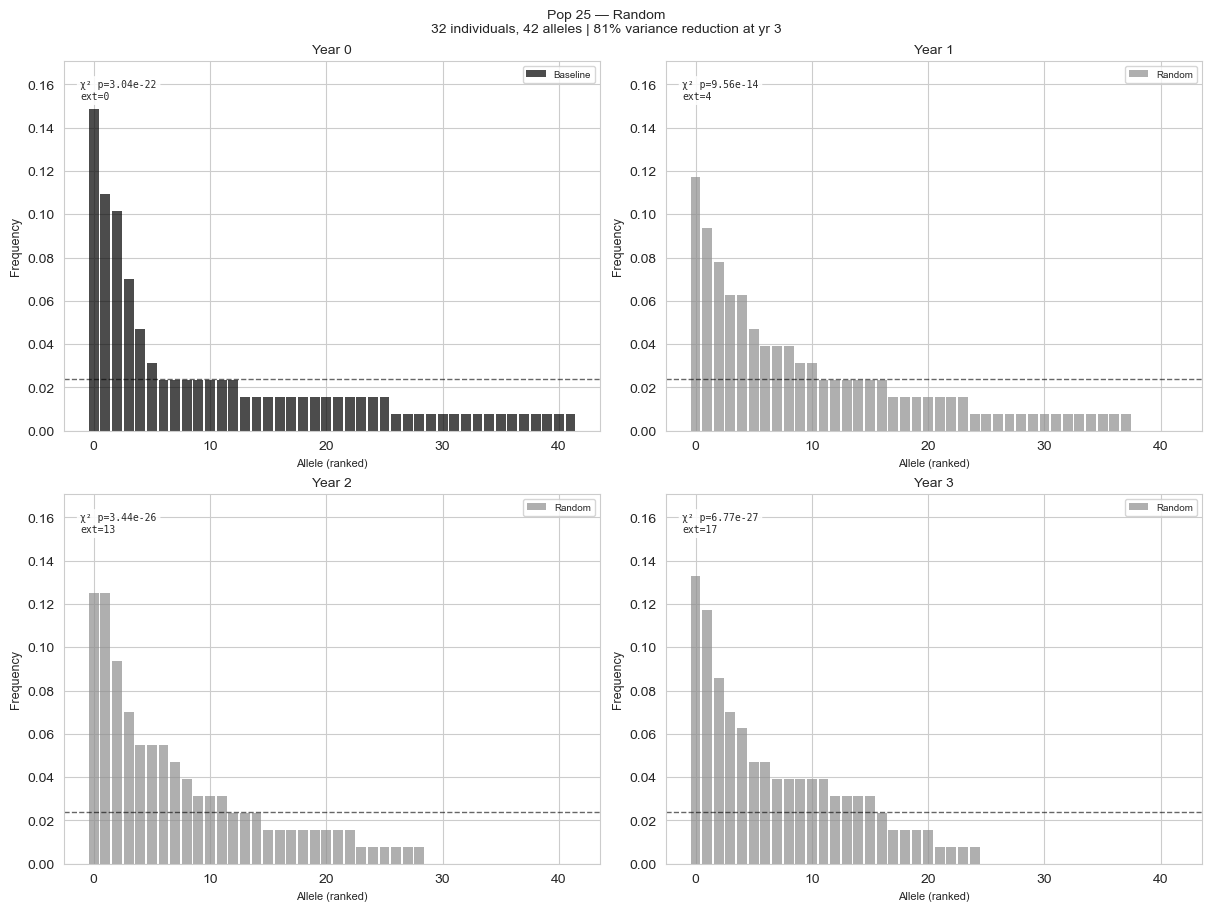

  Saved: ../outputs/figures/pop25_allele_freq_preserved.png


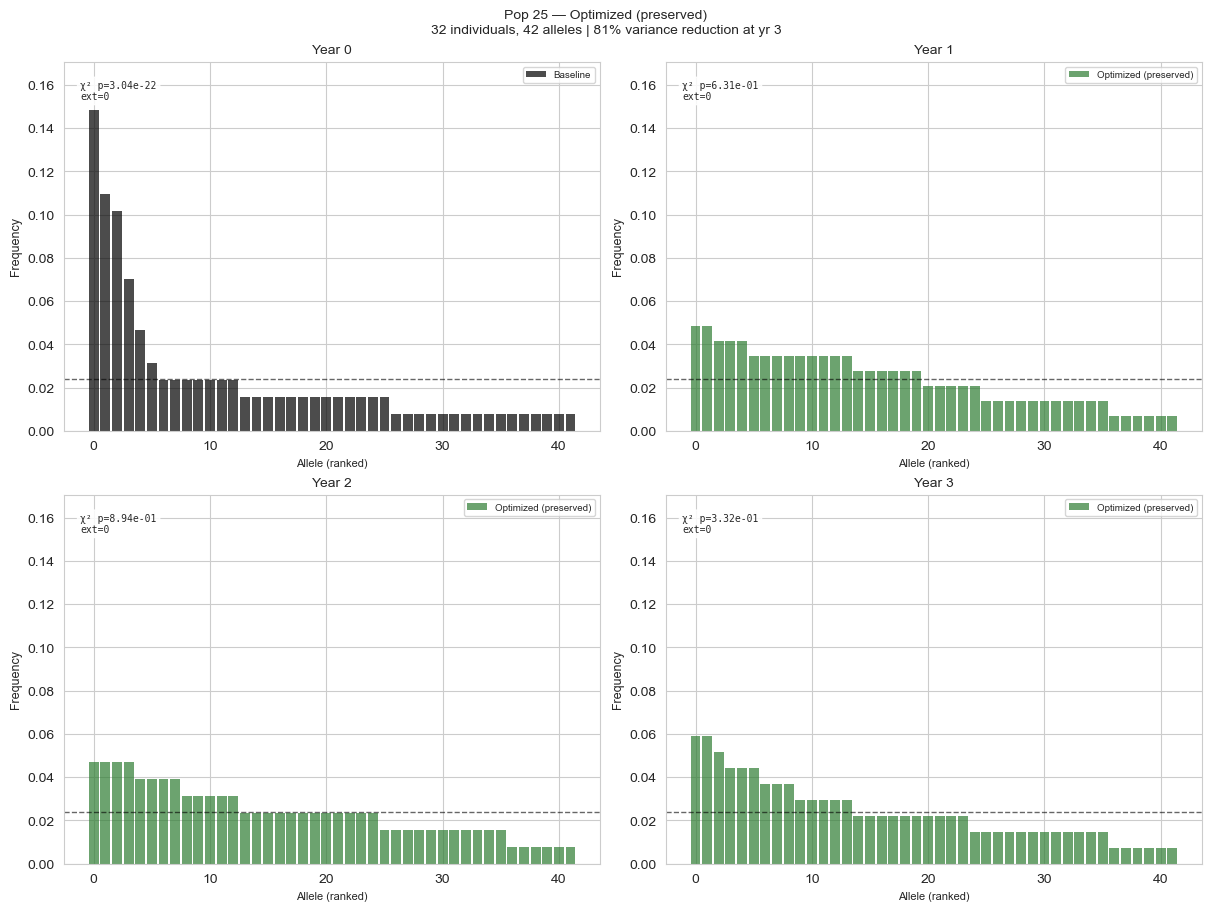

  Saved: ../outputs/figures/pop27_allele_freq_random.png


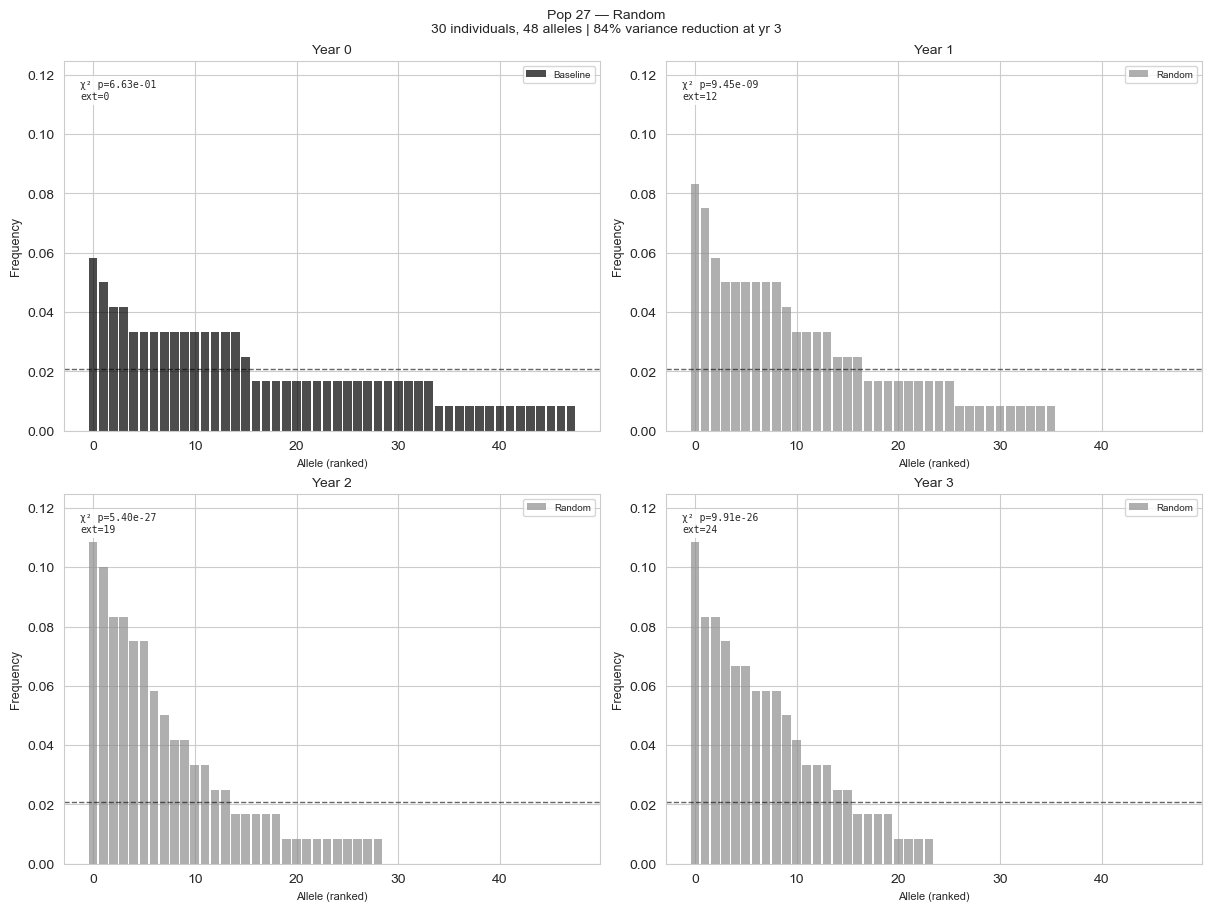

  Saved: ../outputs/figures/pop27_allele_freq_preserved.png


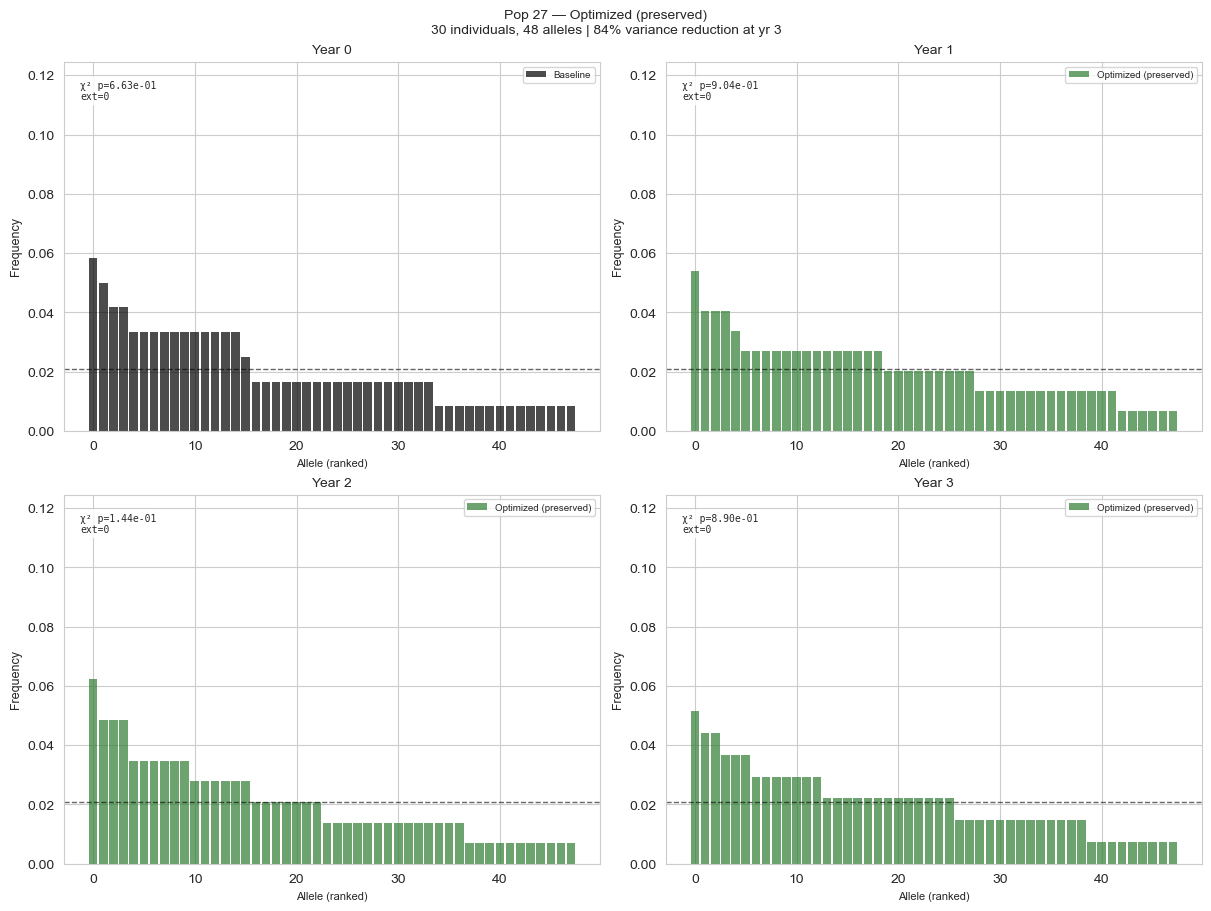

  Saved: ../outputs/figures/pop67_allele_freq_random.png


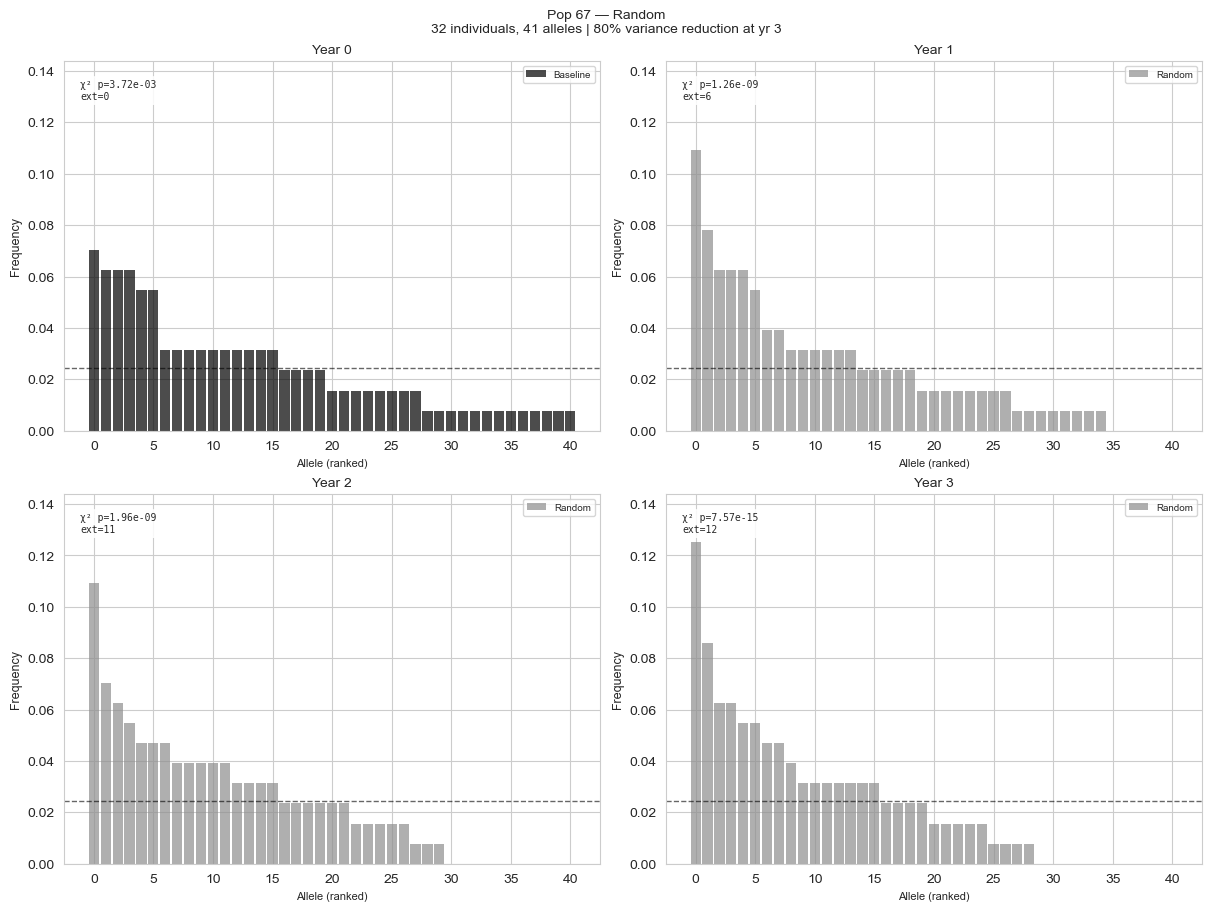

  Saved: ../outputs/figures/pop67_allele_freq_preserved.png


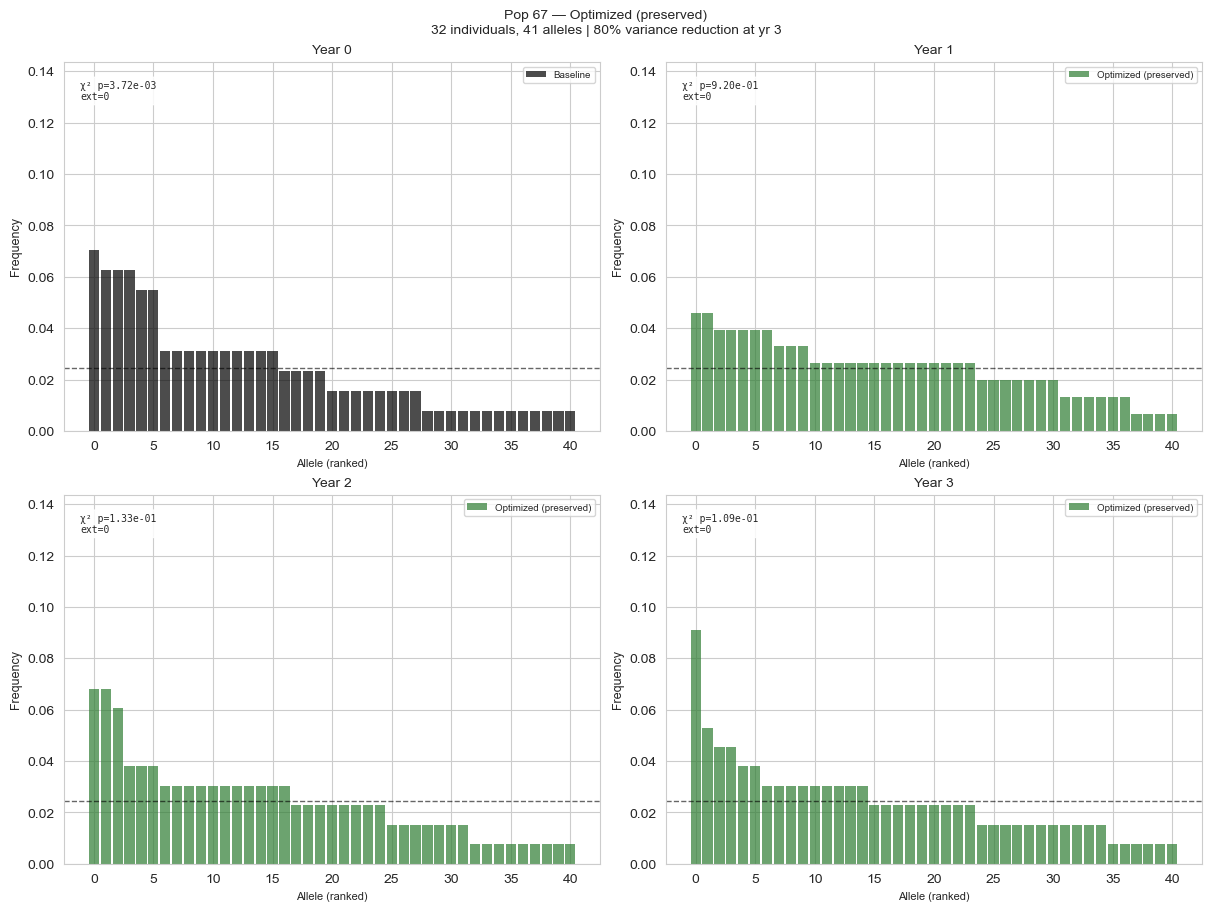

  Saved: ../outputs/figures/pop76_allele_freq_random.png


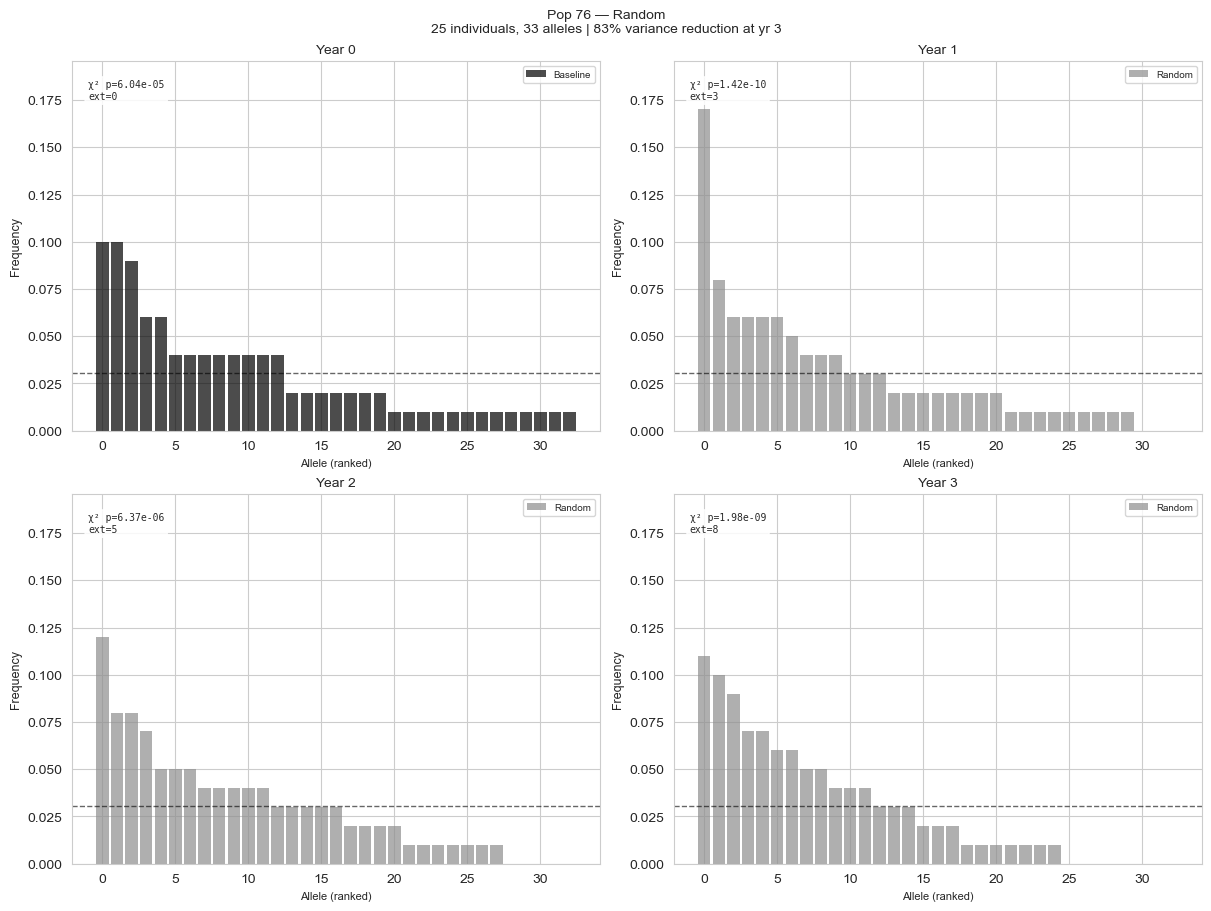

  Saved: ../outputs/figures/pop76_allele_freq_preserved.png


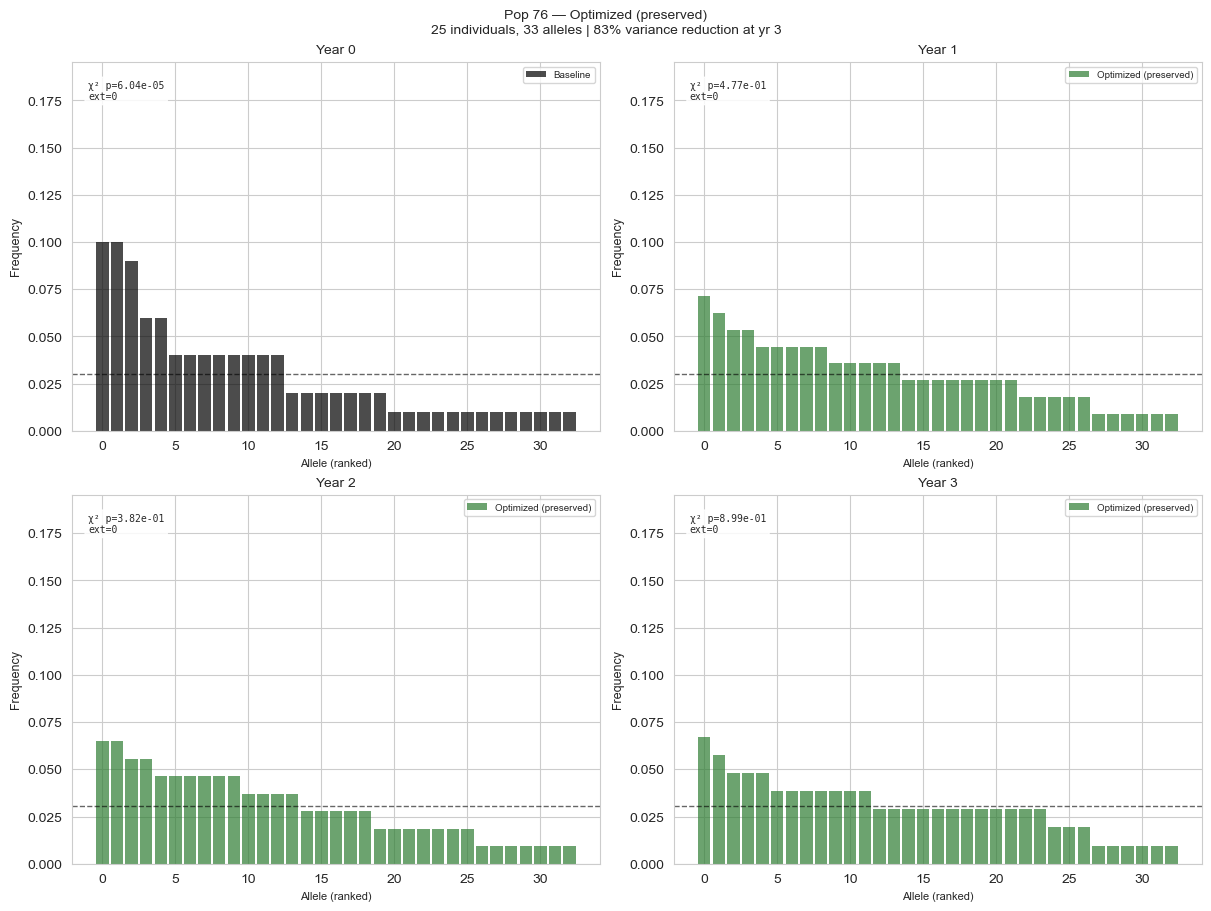

In [66]:
def save_figure(fig, pop_id, strategy_key):
    """Save figure with a descriptive name based on population and strategy."""
    fname = f"pop{pop_id}_allele_freq_{strategy_key}.png"
    path = os.path.join(FIGURES_DIR, fname)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved: {path}")

COLOR_PRESERVED_GREEN = "#2e7d32"

for pop_id in major_pops:
    gd = group_data[pop_id]
    alleles = gd["allele_pool"]
    target = gd["target_freq"]
    n_ind = len(gd["pop"])
    n_alleles = len(alleles)

    y_max = 0
    for yr in SNAPSHOT_YEARS:
        for key in ["random", "optimized", "preserved"]:
            snap = gd[key]["snapshots"].get(yr, gd["pop"])
            f = allele_frequencies(snap, alleles)
            y_max = max(y_max, max(f.values()))
    y_max *= 1.15

    yr3_improv_p = (1 - gd["preserved"]["variance_mean"][3] /
                    max(gd["random"]["variance_mean"][3], 1e-12)) * 100

    for strategy_key, strategy_label, strategy_color in [
        ("random",    "Random",                COLOR_RANDOM),
        ("preserved", "Optimized (preserved)", COLOR_PRESERVED_GREEN),
    ]:
        fig, axes = plt.subplots(2, 2, figsize=(12, 9), layout="constrained")
        fig.suptitle(f"Pop {pop_id} — {strategy_label}\n"
                     f"{n_ind} individuals, {n_alleles} alleles | "
                     f"{yr3_improv_p:.0f}% variance reduction at yr 3",
                     fontsize=10)

        for idx, yr in enumerate(SNAPSHOT_YEARS):
            ax = axes[idx // 2, idx % 2]
            snap = gd[strategy_key]["snapshots"].get(yr, gd["pop"])
            freqs = allele_frequencies(snap, alleles)
            sorted_alleles = sorted(alleles, key=lambda a: freqs.get(a, 0), reverse=True)
            vals = [freqs.get(a, 0) for a in sorted_alleles]
            x = np.arange(len(sorted_alleles))

            color = "black" if yr == 0 else strategy_color
            lbl   = "Baseline" if yr == 0 else strategy_label
            ax.bar(x, vals, width=0.85, color=color, alpha=0.7, edgecolor="none", label=lbl)

            from collections import Counter
            allele_counts = Counter(a for g in snap for a in g)
            obs = np.array([allele_counts.get(a, 0) for a in alleles])
            exp = np.full(len(alleles), obs.sum() / len(alleles))
            _, pval = chisquare(obs, f_exp=exp)
            d = distance_from_equilibrium(snap, alleles)
            ax.text(0.03, 0.95,
                    f"χ² p={pval:.2e}\next={d['extinct_alleles']}",
                    transform=ax.transAxes, ha="left", va="top", fontsize=7,
                    family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

            ax.axhline(y=target, color="blue", linestyle="--", alpha=0.6, linewidth=1)
            ax.set_ylim(0, y_max)
            ax.set_xlabel("Allele (ranked)", fontsize=8)
            ax.set_ylabel("Frequency", fontsize=9)
            ax.set_title(f"Year {yr}", fontsize=10)
            ax.legend(fontsize=7, loc="upper right")

        save_figure(fig, pop_id, strategy_key)
        plt.show()


### Within-Population Convergence: All Strategies

Three metrics over 5 years for each major population. Pop 27 panels are also saved individually.

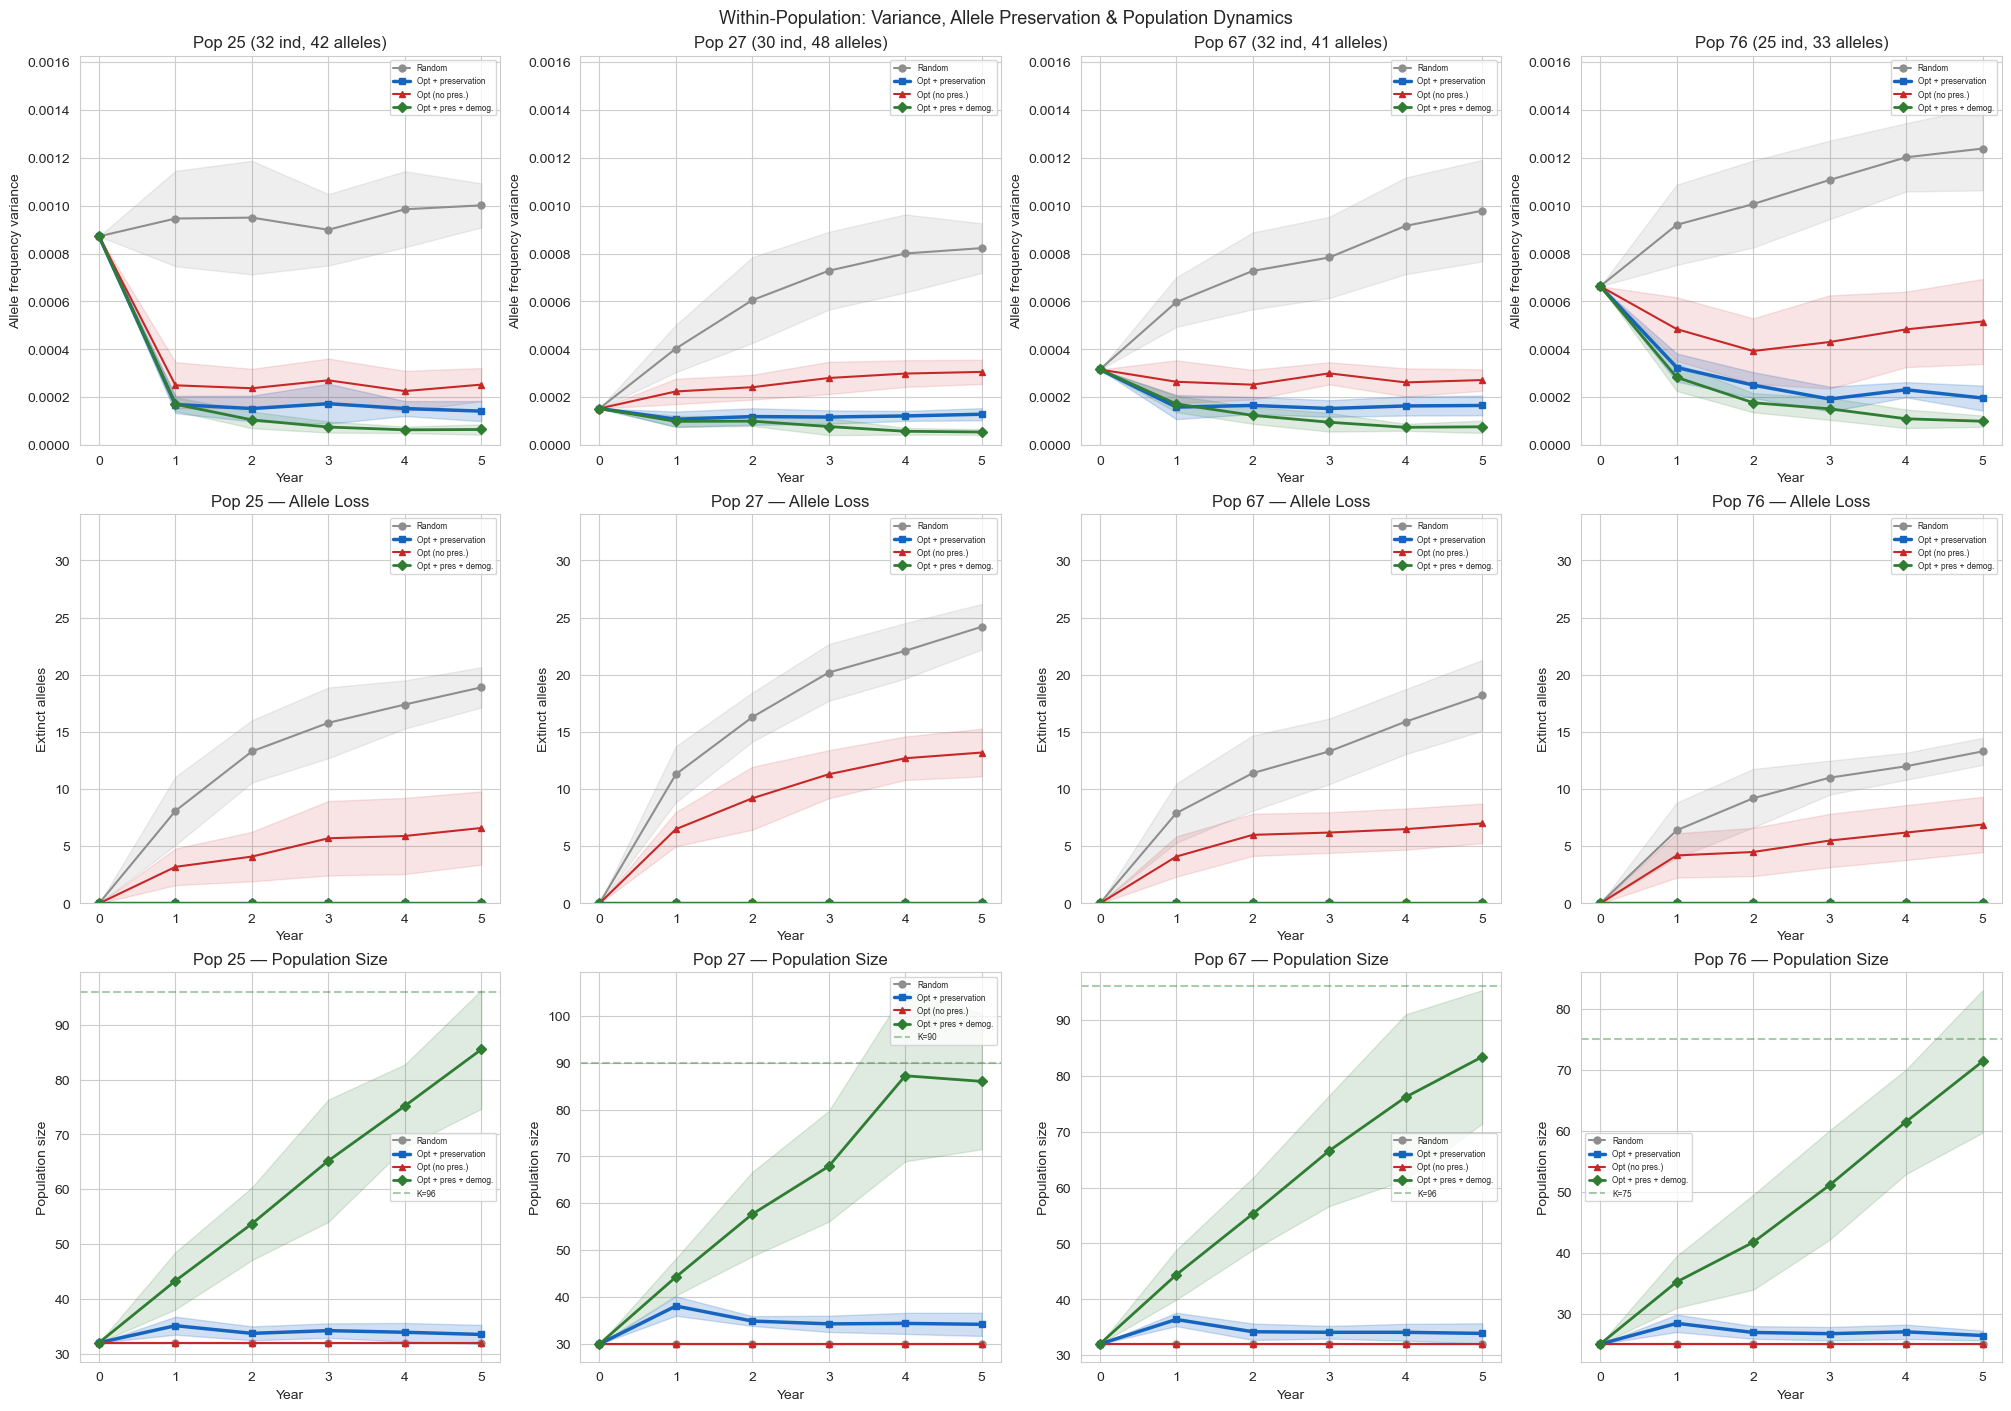

Saved: ../outputs/figures/pop27_convergence_variance.png


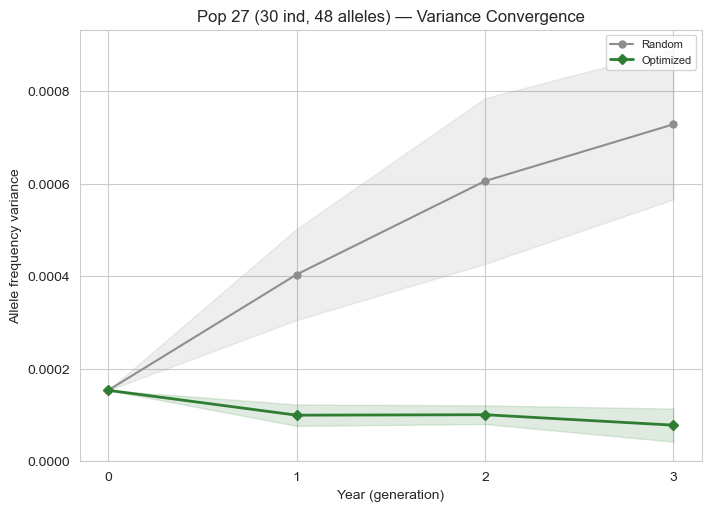

Saved: ../outputs/figures/pop27_convergence_allele_loss.png


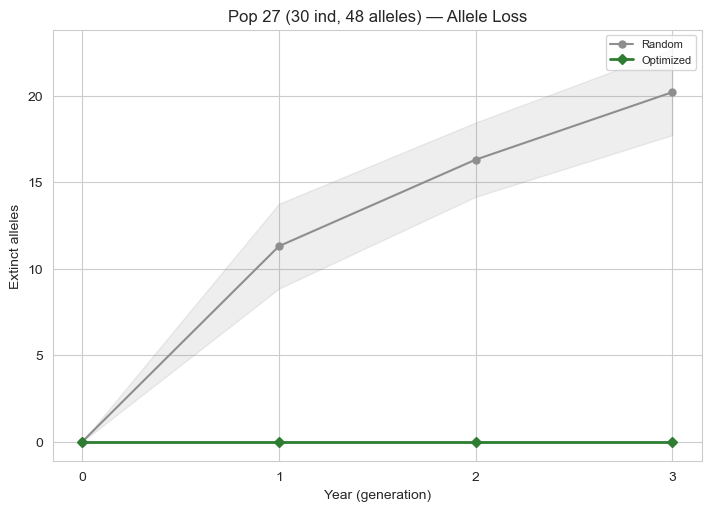

Saved: ../outputs/figures/pop27_convergence_population_size.png


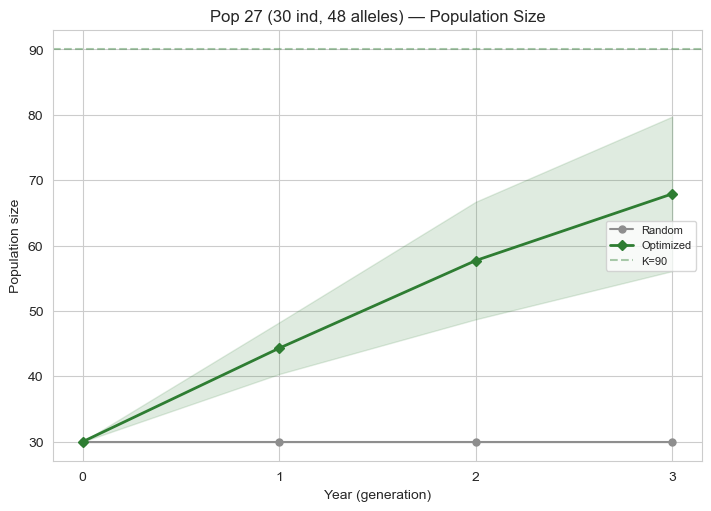

In [19]:
generations = np.arange(N_YEARS + 1)

strategy_specs = [
    ("random",      "Random",               COLOR_RANDOM,      "o", 1.5, 0.15),
    ("preserved",   "Opt + preservation",   COLOR_PRESERVED,   "s", 2.5, 0.2),
    ("optimized",   "Opt (no pres.)",        COLOR_ORIGINAL,    "^", 1.5, 0.12),
    ("demographic", "Opt + pres + demog.",   COLOR_DEMOGRAPHIC, "D", 2.0, 0.15),
]

# Shared y-axis maxima across all populations
y_max_var = 0
y_max_ext = 0
for pop_id in major_pops:
    gd = group_data[pop_id]
    for key in ["random", "optimized", "preserved", "demographic"]:
        res = gd[key]
        y_max_var = max(y_max_var, np.max(res["variance_mean"] + res["variance_std"]))
        y_max_ext = max(y_max_ext, np.max(res["extinct_mean"] + res["extinct_std"]))
y_max_var *= 1.15
y_max_ext = max(y_max_ext * 1.3, 1)

# ---- Combined multi-population grid ----
n_pops = len(major_pops)
fig, axes = plt.subplots(3, n_pops, figsize=(5 * n_pops, 14), layout="constrained")

for idx, pop_id in enumerate(major_pops):
    ax_var = axes[0, idx]
    ax_ext = axes[1, idx]
    ax_pop = axes[2, idx]
    gd = group_data[pop_id]
    N0 = len(gd["pop"])
    K = max(N0 * 3, 30)

    for key, label, color, marker, lw, alpha in strategy_specs:
        res = gd[key]
        for ax, metric in [(ax_var, "variance"), (ax_ext, "extinct"), (ax_pop, "pop_size")]:
            mean_key = f"{metric}_mean"
            std_key  = f"{metric}_std"
            ax.plot(generations, res[mean_key], f"-{marker}", color=color,
                    markersize=5, label=label, linewidth=lw)
            ax.fill_between(generations,
                            res[mean_key] - res[std_key],
                            res[mean_key] + res[std_key],
                            alpha=alpha, color=color)

    ax_var.set_xlabel("Year"); ax_var.set_ylabel("Allele frequency variance")
    ax_var.set_title(f"Pop {pop_id} ({N0} ind, {len(gd['allele_pool'])} alleles)")
    ax_var.legend(fontsize=6); ax_var.set_xticks(generations)
    ax_var.set_ylim(0, y_max_var)

    ax_ext.set_xlabel("Year"); ax_ext.set_ylabel("Extinct alleles")
    ax_ext.set_title(f"Pop {pop_id} — Allele Loss")
    ax_ext.legend(fontsize=6); ax_ext.set_xticks(generations)
    ax_ext.set_ylim(0, y_max_ext)

    ax_pop.axhline(K, color=COLOR_DEMOGRAPHIC, linestyle="--", alpha=0.4, label=f"K={K}")
    ax_pop.set_xlabel("Year"); ax_pop.set_ylabel("Population size")
    ax_pop.set_title(f"Pop {pop_id} — Population Size")
    ax_pop.legend(fontsize=6); ax_pop.set_xticks(generations)

fig.suptitle("Within-Population: Variance, Allele Preservation & Population Dynamics", fontsize=13)
plt.show()

# ---- Save Pop 27 panels as individual figures (years 0–3, Random vs Optimized only) ----
if "27" in major_pops:
    gd27 = group_data["27"]
    N0_27 = len(gd27["pop"])
    K_27  = max(N0_27 * 3, 30)
    pop27_gens = np.arange(4)  # generations 0, 1, 2, 3
    pop27_specs = [
        ("random",      "Random",    COLOR_RANDOM,      "o", 1.5, 0.15),
        ("demographic", "Optimized", COLOR_DEMOGRAPHIC, "D", 2.0, 0.15),
    ]

    for metric, ylabel, title_suffix, fname in [
        ("variance",  "Allele frequency variance", "Variance Convergence",  "pop27_convergence_variance.png"),
        ("extinct",   "Extinct alleles",            "Allele Loss",           "pop27_convergence_allele_loss.png"),
        ("pop_size",  "Population size",            "Population Size",       "pop27_convergence_population_size.png"),
    ]:
        fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
        for key, label, color, marker, lw, alpha in pop27_specs:
            res = gd27[key]
            mean_vals = res[f"{metric}_mean"][:4]
            std_vals  = res[f"{metric}_std"][:4]
            ax.plot(pop27_gens, mean_vals, f"-{marker}", color=color,
                    markersize=5, label=label, linewidth=lw)
            ax.fill_between(pop27_gens, mean_vals - std_vals, mean_vals + std_vals,
                            alpha=alpha, color=color)
        if metric == "pop_size":
            ax.axhline(K_27, color=COLOR_DEMOGRAPHIC, linestyle="--", alpha=0.4, label=f"K={K_27}")
        ax.set_xlabel("Year (generation)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Pop 27 ({N0_27} ind, {len(gd27['allele_pool'])} alleles) — {title_suffix}")
        ax.legend(fontsize=8)
        ax.set_xticks(pop27_gens)
        path = os.path.join(FIGURES_DIR, fname)
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"Saved: {path}")
        plt.show()

### Strategy Comparison: Variance Reduction & Allele Loss

Within-Population Strategy Comparison
Pres% = preservation vs random | Demo% = demographic vs random
Pop  N  K  Alleles  Initial var Pres% (yr1) Demo% (yr1)  Ext Rand (yr1)  Ext Pres (yr1)  Ext Demo (yr1) Pres% (yr2) Demo% (yr2)  Ext Rand (yr2)  Ext Pres (yr2)  Ext Demo (yr2) Pres% (yr5) Demo% (yr5)  Ext Rand (yr5)  Ext Pres (yr5)  Ext Demo (yr5)
 25 32 96       42       0.0009         82%         82%          8.1000          0.0000          0.0000         84%         89%         13.3000          0.0000          0.0000         86%         93%         18.9000          0.0000          0.0000
 27 30 90       48       0.0002         73%         75%         11.3000          0.0000          0.0000         80%         83%         16.3000          0.0000          0.0000         84%         93%         24.2000          0.0000          0.0000
 67 32 96       41       0.0003         73%         71%          7.9000          0.0000          0.0000         77%         83%         11.4000          0.

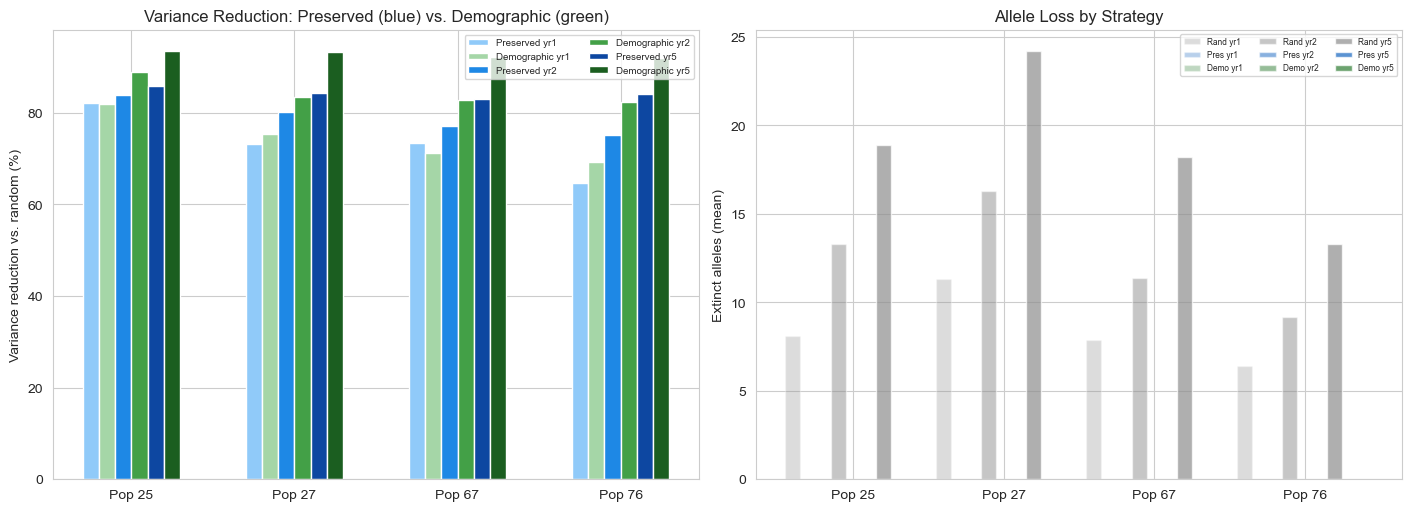

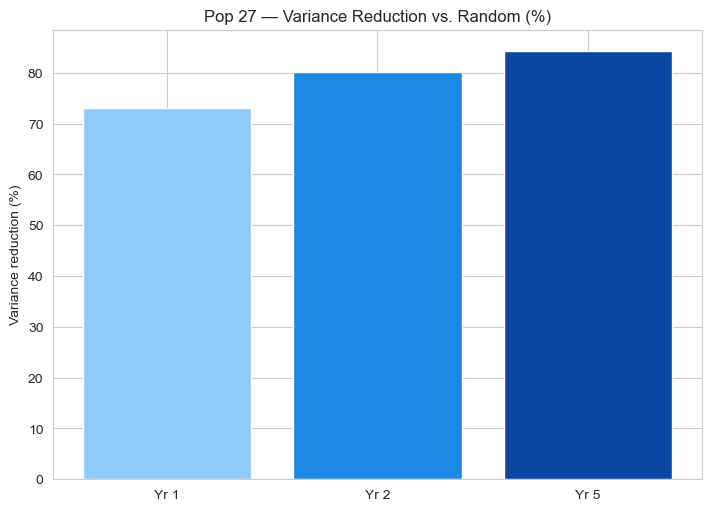

Saved: ../outputs/figures/pop27_strategy_comparison_allele_loss.png


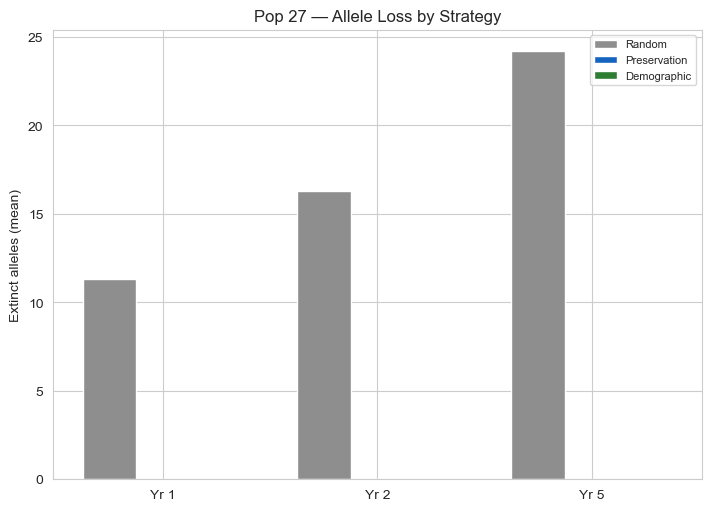

In [21]:
improvement_rows = []
for pop_id in major_pops:
    gd = group_data[pop_id]
    r = gd["random"]; o = gd["optimized"]; p = gd["preserved"]; dm = gd["demographic"]
    N0 = len(gd["pop"]); K = max(N0 * 3, 30)
    row = {"Pop": pop_id, "N": N0, "K": K, "Alleles": len(gd["allele_pool"]),
           "Initial var": r["variance_mean"][0]}
    for yr in [1, 2, 5]:
        rv = r["variance_mean"][yr]; pv = p["variance_mean"][yr]; dv = dm["variance_mean"][yr]
        row[f"Pres% (yr{yr})"]    = f"{(1 - pv / max(rv, 1e-12)) * 100:.0f}%"
        row[f"Demo% (yr{yr})"]    = f"{(1 - dv / max(rv, 1e-12)) * 100:.0f}%"
        row[f"Ext Rand (yr{yr})"] = r["extinct_mean"][yr]
        row[f"Ext Pres (yr{yr})"] = p["extinct_mean"][yr]
        row[f"Ext Demo (yr{yr})"] = dm["extinct_mean"][yr]
    improvement_rows.append(row)

imp_df = pd.DataFrame(improvement_rows)
print("Within-Population Strategy Comparison")
print("Pres% = preservation vs random | Demo% = demographic vs random")
print("=" * 120)
print(imp_df.to_string(index=False, float_format="{:.4f}".format))

# Bar chart: variance reduction % and allele extinction
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")
x = np.arange(len(major_pops))
width = 0.1

for i, yr in enumerate([1, 2, 5]):
    imps_p, imps_d, exts_r, exts_p, exts_d = [], [], [], [], []
    for pop_id in major_pops:
        gd = group_data[pop_id]
        rv = gd["random"]["variance_mean"][yr]
        pv = gd["preserved"]["variance_mean"][yr]
        dv = gd["demographic"]["variance_mean"][yr]
        imps_p.append((1 - pv / max(rv, 1e-12)) * 100)
        imps_d.append((1 - dv / max(rv, 1e-12)) * 100)
        exts_r.append(gd["random"]["extinct_mean"][yr])
        exts_p.append(gd["preserved"]["extinct_mean"][yr])
        exts_d.append(gd["demographic"]["extinct_mean"][yr])

    blue_shades  = ["#90caf9", "#1e88e5", "#0d47a1"]
    green_shades = ["#a5d6a7", "#43a047", "#1b5e20"]
    ax1.bar(x + i * width * 2,         imps_p, width, label=f"Preserved yr{yr}",   color=blue_shades[i])
    ax1.bar(x + i * width * 2 + width, imps_d, width, label=f"Demographic yr{yr}", color=green_shades[i])
    ax2.bar(x + i * width * 3,             exts_r, width, label=f"Rand yr{yr}", color=COLOR_RANDOM,      alpha=0.3 + 0.2*i)
    ax2.bar(x + i * width * 3 + width,     exts_p, width, label=f"Pres yr{yr}", color=COLOR_PRESERVED,   alpha=0.3 + 0.2*i)
    ax2.bar(x + i * width * 3 + 2*width,   exts_d, width, label=f"Demo yr{yr}", color=COLOR_DEMOGRAPHIC, alpha=0.3 + 0.2*i)

ax1.set_xticks(x + width * 2.5)
ax1.set_xticklabels([f"Pop {p}" for p in major_pops])
ax1.set_ylabel("Variance reduction vs. random (%)")
ax1.set_title("Variance Reduction: Preserved (blue) vs. Demographic (green)")
ax1.legend(fontsize=7, ncol=2)
ax1.axhline(y=0, color="gray", linewidth=0.5)

ax2.set_xticks(x + width * 4)
ax2.set_xticklabels([f"Pop {p}" for p in major_pops])
ax2.set_ylabel("Extinct alleles (mean)")
ax2.set_title("Allele Loss by Strategy")
ax2.legend(fontsize=6, ncol=3)

# Save Pop 27 strategy comparison as individual figure
if "27" in major_pops:
    idx27 = major_pops.index("27")
    for fig_title, metric_label, metric_fn, fname in [
        ("Variance Reduction vs. Random (%)", "Variance reduction (%)",
         lambda gd, yr: (1 - gd["preserved"]["variance_mean"][yr] /
                         max(gd["random"]["variance_mean"][yr], 1e-12)) * 100,
         "pop27_strategy_comparison_variance_reduction.png"),
        ("Allele Loss by Strategy", "Extinct alleles (mean)",
         None, "pop27_strategy_comparison_allele_loss.png"),
    ]:
        fig27, ax27 = plt.subplots(figsize=(7, 5), layout="constrained")
        gd27 = group_data["27"]
        years_plot = [1, 2, 5]
        if metric_fn is not None:
            vals = [metric_fn(gd27, yr) for yr in years_plot]
            ax27.bar(range(len(years_plot)), vals, color=["#90caf9", "#1e88e5", "#0d47a1"],
                     tick_label=[f"Yr {yr}" for yr in years_plot])
            ax27.set_ylabel(metric_label)
        else:
            w2 = 0.25
            xs = np.arange(len(years_plot))
            ax27.bar(xs - w2,   [gd27["random"]["extinct_mean"][yr] for yr in years_plot],
                     w2, label="Random", color=COLOR_RANDOM)
            ax27.bar(xs,        [gd27["preserved"]["extinct_mean"][yr] for yr in years_plot],
                     w2, label="Preservation", color=COLOR_PRESERVED)
            ax27.bar(xs + w2,   [gd27["demographic"]["extinct_mean"][yr] for yr in years_plot],
                     w2, label="Demographic", color=COLOR_DEMOGRAPHIC)
            ax27.set_xticks(xs)
            ax27.set_xticklabels([f"Yr {yr}" for yr in years_plot])
            ax27.set_ylabel(metric_label)
            ax27.legend(fontsize=8)
        ax27.set_title(f"Pop 27 — {fig_title}")
        path = os.path.join(FIGURES_DIR, fname)
        fig27.savefig(path, dpi=150, bbox_inches="tight")
        print(f"Saved: {path}")
        plt.show()

plt.show()

### Top Recommended Crosses (Per Population)

In [23]:
for pop_id in major_pops:
    gd = group_data[pop_id]
    cc = gd["compatible_crosses"]
    ow = gd["optimal_weights"]
    names = gd["individuals"]
    target = gd["target_freq"]
    d = distance_from_equilibrium(gd["pop"], gd["allele_pool"])
    aem = gd["allele_effect_matrix"]

    rows = []
    for k in range(len(cc)):
        i, j, compat = cc[k]
        expected_freqs = aem[k]
        chi_sq = float(np.sum((expected_freqs - target) ** 2 / target))
        rows.append({
            "Maternal": names[i], "Pollen donor": names[j],
            "Compatibility": compat, "Impact score": d["chi_squared"] - chi_sq,
            "Optimal weight": ow[k],
        })

    df = pd.DataFrame(rows)
    df_top = df.nlargest(10, "Optimal weight").copy()
    df_top.insert(0, "Rank", range(1, len(df_top) + 1))

    print(f"\n{'='*80}")
    print(f"Top 10 Crosses — Pop {pop_id} ({len(gd['pop'])} ind, {len(gd['allele_pool'])} alleles)")
    print(f"{'='*80}")
    print(df_top.to_string(index=False, float_format="{:.4f}".format))


Top 10 Crosses — Pop 25 (32 ind, 42 alleles)
 Rank             Maternal         Pollen donor  Compatibility  Impact score  Optimal weight
    1 Library003_barcode74 Library003_barcode61         0.1667       -5.3372          0.0983
    2 Library001_barcode10 Library003_barcode62         0.1667       -6.6497          0.0705
    3 Library005_barcode23 Library005_barcode24         0.1667       -6.6497          0.0656
    4 Library005_barcode24 Library005_barcode23         0.1667       -6.6497          0.0524
    5 Library003_barcode74 Library003_barcode65         0.1667      -10.5872          0.0492
    6 Library005_barcode28 Library004_barcode83         0.1667      -13.2122          0.0300
    7 Library003_barcode74 Library005_barcode29         0.1667      -10.5872          0.0246
    8 Library003_barcode74 Library005_barcode30         0.1667      -10.5872          0.0246
    9 Library005_barcode22 Library005_barcode33         1.0000       -5.3372          0.0198
   10 Library005_barcode

## Part B: Cross-Population Analysis

All ingroup individuals treated as a single metapopulation. Allows the optimizer to identify
inter-population crosses — especially valuable for singleton alleles carried by individuals
from minor or isolated populations.

In [25]:
%%time

global_alleles = sorted(set(a for g in population_genotypes for a in g))
global_target  = 1.0 / len(global_alleles)
N_global       = len(population_genotypes)
K_global       = max(N_global * 2, 200)

print(f"Global population: {N_global} individuals, {len(global_alleles)} alleles")
print(f"Target frequency: 1/{len(global_alleles)} = {global_target:.4f}")
print(f"Carrying capacity K = {K_global}")
print(f"Total directed pairs: {N_global * (N_global - 1)}")
print("Enumerating compatible crosses...")

global_cc, global_aem = enumerate_compatible_crosses(population_genotypes, global_alleles)
n_total = N_global * (N_global - 1)
print(f"Compatible crosses: {len(global_cc)}/{n_total} ({100*len(global_cc)/n_total:.1f}%)")

# Optimize weights
w0 = np.ones(len(global_cc)) / len(global_cc)
expected = w0 @ global_aem
baseline_chi = float(np.sum((expected - global_target) ** 2 / global_target))
print("Optimizing crossing weights...")
global_optimal_weights, global_opt_result = compute_optimal_weights(
    global_cc, global_aem, global_alleles, maxiter=5000)
print(f"Baseline χ²: {baseline_chi:.4f} → Optimized χ²: {global_opt_result.fun:.6f} "
      f"(converged={global_opt_result.success})")

Global population: 152 individuals, 202 alleles
Target frequency: 1/202 = 0.0050
Carrying capacity K = 304
Total directed pairs: 22952
Enumerating compatible crosses...
Compatible crosses: 22828/22952 (99.5%)
Optimizing crossing weights...
Baseline χ²: 0.9776 → Optimized χ²: 0.026458 (converged=True)
CPU times: user 28.4 s, sys: 7.95 s, total: 36.3 s
Wall time: 4.5 s


In [ ]:
%%time

print(f"Simulating {N_YEARS} years ({N_global} individuals, K={K_global})...")

print("Random mating...")
global_random = run_adaptive_simulation(
    population_genotypes, global_alleles, N_YEARS, "random", N_TRIALS, base_seed=BASE_SEED)

print("Optimized (no preservation)...")
global_optimized = run_adaptive_simulation(
    population_genotypes, global_alleles, N_YEARS, "optimized", N_TRIALS, base_seed=BASE_SEED)

print("Optimized + preservation...")
global_preserved = run_adaptive_simulation(
    population_genotypes, global_alleles, N_YEARS, "optimized", N_TRIALS,
    preserve_rare=True, rare_threshold=0.05, elite_frac=0.1, base_seed=BASE_SEED)

print("Optimized + preservation + demography...")
global_demographic = run_adaptive_simulation(
    population_genotypes, global_alleles, N_YEARS, "optimized", N_TRIALS,
    preserve_rare=True, rare_threshold=0.05, elite_frac=0.1,
    carrying_capacity=K_global, growth_rate=0.5, demographic_stochastic=True,
    base_seed=BASE_SEED)

print("\nResults:")
for yr in SNAPSHOT_YEARS:
    rv = global_random["variance_mean"][yr]
    pv = global_preserved["variance_mean"][yr]
    dv = global_demographic["variance_mean"][yr]
    print(f"  Year {yr}: Random var={rv:.6f}, "
          f"Pres={pv:.6f} ({(1-pv/max(rv,1e-12))*100:.0f}%), "
          f"Demo={dv:.6f} ({(1-dv/max(rv,1e-12))*100:.0f}%) | "
          f"Extinct R={global_random['extinct_mean'][yr]:.1f}, "
          f"P={global_preserved['extinct_mean'][yr]:.1f}, "
          f"D={global_demographic['extinct_mean'][yr]:.1f}")

Simulating 5 years (152 individuals, K=304)...
Random mating...
Optimized (no preservation)...


/var/folders/7q/9sxlsr1j6xg80n7_3mmyx_nr0000gp/T/ipykernel_91674/2326443061.py:127: RuntimeWarning: Mean of empty slice
  "ne_mean":          np.where(np.all(np.isnan(all_ne), axis=0), np.nan, np.nanmean(all_ne, axis=0)),
/Users/sven/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Optimized + preservation...
Optimized + preservation + demography...


### Cross-Population Allele Frequencies by Strategy

In [ ]:
yr3_rv = global_random["variance_mean"][3]
yr3_pv = global_preserved["variance_mean"][3]
yr3_improv_p = (1 - yr3_pv / max(yr3_rv, 1e-12)) * 100
yr3_ext_p = global_preserved["extinct_mean"][3]

COLOR_PRESERVED_GREEN = "#2e7d32"

y_max = 0
for yr in SNAPSHOT_YEARS:
    for res in [global_random, global_preserved]:
        snap = res["snapshots"].get(yr, population_genotypes)
        f = allele_frequencies(snap, global_alleles)
        y_max = max(y_max, max(f.values()))
y_max *= 1.15

for strategy_res, strategy_label, strategy_color, ext_line, fname in [
    (global_random,    "Random",               COLOR_RANDOM,
     f"{yr3_improv_p:.0f}% variance reduction at yr 3",
     "cross_pop_allele_freq_random.png"),
    (global_preserved, "Optimized (preserved)", COLOR_PRESERVED_GREEN,
     f"Extinct at yr 3: preserved={yr3_ext_p:.1f}",
     "cross_pop_allele_freq_random_vs_preservation.png"),
]:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), layout="constrained")
    fig.suptitle(f"All Populations Combined — {strategy_label}\n"
                 f"{N_global} individuals, {len(global_alleles)} alleles | {ext_line}",
                 fontsize=10)

    for idx, yr in enumerate(SNAPSHOT_YEARS):
        ax = axes[idx // 2, idx % 2]
        snap = strategy_res["snapshots"].get(yr, population_genotypes)
        freqs = allele_frequencies(snap, global_alleles)
        sorted_alleles = sorted(global_alleles, key=lambda a: freqs.get(a, 0), reverse=True)
        vals = [freqs.get(a, 0) for a in sorted_alleles]
        x = np.arange(len(sorted_alleles))

        color = "black" if yr == 0 else strategy_color
        lbl   = "Baseline" if yr == 0 else strategy_label
        ax.bar(x, vals, width=0.85, color=color, alpha=0.7, edgecolor="none", label=lbl)

        # Chi-square goodness-of-fit vs uniform equilibrium
        from collections import Counter
        allele_counts = Counter(a for g in snap for a in g)
        obs = np.array([allele_counts.get(a, 0) for a in global_alleles])
        exp = np.full(len(global_alleles), obs.sum() / len(global_alleles))
        _, pval = chisquare(obs, f_exp=exp)
        d = distance_from_equilibrium(snap, global_alleles)
        ax.text(0.03, 0.95,
                f"χ² p={pval:.2e}\next={d['extinct_alleles']}",
                transform=ax.transAxes, ha="left", va="top", fontsize=7,
                family="monospace",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

        ax.axhline(y=global_target, color="blue", linestyle="--", alpha=0.6, linewidth=1)
        ax.set_ylim(0, y_max)
        ax.set_xlabel("Allele (ranked)", fontsize=8)
        ax.set_ylabel("Frequency", fontsize=9)
        ax.set_title(f"Year {yr}", fontsize=10)
        ax.legend(fontsize=7, loc="upper right")

    path = os.path.join(FIGURES_DIR, fname)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()


### Cross-Population Convergence

In [ ]:
global_strategy_specs = [
    (global_random,      "Random",               COLOR_RANDOM,      "o", 1.5, 0.15),
    (global_preserved,   "Opt + preservation",   COLOR_PRESERVED,   "s", 2.5, 0.2),
    (global_optimized,   "Opt (no pres.)",        COLOR_ORIGINAL,    "^", 1.5, 0.12),
    (global_demographic, "Opt + pres + demog.",   COLOR_DEMOGRAPHIC, "D", 2.0, 0.15),
]

for metric, ylabel, title_suffix, fname in [
    ("variance",  "Allele frequency variance", "Variance Convergence",  "cross_pop_convergence_variance.png"),
    ("extinct",   "Extinct alleles",            "Allele Loss",           "cross_pop_convergence_allele_loss.png"),
    ("pop_size",  "Population size",            "Population Size",       "cross_pop_convergence_population_size.png"),
]:
    fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
    for res, label, color, marker, lw, alpha in global_strategy_specs:
        mean_vals = res[f"{metric}_mean"]
        std_vals  = res[f"{metric}_std"]
        ax.plot(generations, mean_vals, f"-{marker}", color=color,
                markersize=5, label=label, linewidth=lw)
        ax.fill_between(generations, mean_vals - std_vals, mean_vals + std_vals,
                        alpha=alpha, color=color)
    if metric == "pop_size":
        ax.axhline(K_global, color=COLOR_DEMOGRAPHIC, linestyle="--", alpha=0.4, label=f"K={K_global}")
    ax.set_xlabel("Year (generation)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"All Populations Combined ({N_global} ind, {len(global_alleles)} alleles) — {title_suffix}")
    ax.legend(fontsize=8)
    ax.set_xticks(generations)
    path = os.path.join(FIGURES_DIR, fname)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()

### Top Cross-Population Recommended Crosses

In [ ]:
d_global = distance_from_equilibrium(population_genotypes, global_alleles)

rows = []
for k in range(len(global_cc)):
    i, j, compat = global_cc[k]
    expected_freqs = global_aem[k]
    chi_sq = float(np.sum((expected_freqs - global_target) ** 2 / global_target))
    mat_name = individual_names[i]
    pat_name = individual_names[j]
    rows.append({
        "Maternal":       mat_name,
        "Mat. Pop":       pop_map[mat_name],
        "Pollen donor":   pat_name,
        "Don. Pop":       pop_map[pat_name],
        "Cross type":     "inter-pop" if pop_map[mat_name] != pop_map[pat_name] else "intra-pop",
        "Compatibility":  compat,
        "Impact score":   d_global["chi_squared"] - chi_sq,
        "Optimal weight": global_optimal_weights[k],
    })

df_global = pd.DataFrame(rows)
df_top = df_global.nlargest(20, "Optimal weight").copy()
df_top.insert(0, "Rank", range(1, len(df_top) + 1))

print("Top 20 Cross-Population Crosses")
print("=" * 120)
print(df_top.to_string(index=False, float_format="{:.4f}".format))

n_inter = (df_global["Cross type"] == "inter-pop").sum()
n_intra = (df_global["Cross type"] == "intra-pop").sum()
top20_inter = (df_top["Cross type"] == "inter-pop").sum()
print(f"\nAll compatible crosses: {n_intra} intra-pop, {n_inter} inter-pop")
print(f"Top 20 by weight:       {20 - top20_inter} intra-pop, {top20_inter} inter-pop")

## Summary

In [ ]:
summary_rows = []

for pop_id in major_pops:
    gd = group_data[pop_id]
    r = gd["random"]; p = gd["preserved"]; dm = gd["demographic"]
    d = distance_from_equilibrium(gd["pop"], gd["allele_pool"])
    N0 = len(gd["pop"]); K = max(N0 * 3, 30)
    row = {
        "Analysis": f"Pop {pop_id}", "N": N0, "K": K,
        "Alleles": len(gd["allele_pool"]), "Crosses": len(gd["compatible_crosses"]),
        "Initial χ²": d["chi_squared"], "Optimized χ²": gd["opt_result"].fun,
    }
    for yr in [1, 2, 5]:
        rv = r["variance_mean"][yr]; pv = p["variance_mean"][yr]; dv = dm["variance_mean"][yr]
        row[f"Yr{yr} Pres%"]     = f"{(1 - pv / max(rv, 1e-12)) * 100:.0f}%"
        row[f"Yr{yr} Demo%"]     = f"{(1 - dv / max(rv, 1e-12)) * 100:.0f}%"
        row[f"Yr{yr} Ext(R/P/D)"] = (f"{r['extinct_mean'][yr]:.0f}/"
                                      f"{p['extinct_mean'][yr]:.0f}/"
                                      f"{dm['extinct_mean'][yr]:.0f}")
        row[f"Yr{yr} Pop(D)"]    = f"{dm['pop_size_mean'][yr]:.0f}"
    summary_rows.append(row)

# Cross-population row
cr = global_random; cp = global_preserved; cd = global_demographic
row = {
    "Analysis": "ALL (cross-pop)", "N": N_global, "K": K_global,
    "Alleles": len(global_alleles), "Crosses": len(global_cc),
    "Initial χ²": baseline_chi, "Optimized χ²": global_opt_result.fun,
}
for yr in [1, 2, 5]:
    rv = cr["variance_mean"][yr]; pv = cp["variance_mean"][yr]; dv = cd["variance_mean"][yr]
    row[f"Yr{yr} Pres%"]      = f"{(1 - pv / max(rv, 1e-12)) * 100:.0f}%"
    row[f"Yr{yr} Demo%"]      = f"{(1 - dv / max(rv, 1e-12)) * 100:.0f}%"
    row[f"Yr{yr} Ext(R/P/D)"] = (f"{cr['extinct_mean'][yr]:.0f}/"
                                   f"{cp['extinct_mean'][yr]:.0f}/"
                                   f"{cd['extinct_mean'][yr]:.0f}")
    row[f"Yr{yr} Pop(D)"]     = f"{cd['pop_size_mean'][yr]:.0f}"
summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("Full Summary — filespopulation27 dataset")
print("Ext(R/P/D) = Extinct alleles for Random / Preserved / Demographic at that year")
print("=" * 160)
print(summary_df.to_string(index=False, float_format="{:.4f}".format))

print("\n\nFigures saved to:", os.path.abspath(FIGURES_DIR))
saved = sorted(os.listdir(FIGURES_DIR))
for f in saved:
    print(f"  {f}")